In [1]:
#==========================================================================
# Libraries
#==========================================================================

import pickle
import dill
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import scipy.io
import pandas as pd
import time
from gekko import GEKKO
from tqdm import tqdm
import copy
import importlib
import sys
import os

#==========================================================================
# Functions
#==========================================================================

# main_folder_path = '/Users/mayaharris/Documents/GitHub/pyssem/pyssem'
main_folder_path = '/Users/glavezzi/Desktop/pyssem/pyssem/'

sys.path.append(main_folder_path) 
import utils.control.control  
importlib.reload(utils.control.control)
from utils.control.control import *

from utils.drag.drag import calculate_orbital_lifetimes

#==========================================================================
# Plotting settings
#==========================================================================
sel_LineWidth = 3
sel_LineWidth2 = 1.5
sel_MarkerWidth = 10
sel_LineWidthAxis = 1
sel_FontSize = 14  
# folder = '/Users/glavezzi/Library/CloudStorage/Box-Box/MIT/PROJETCS/SSEM/Draft/AAS24/figure' 

In [2]:
# --------------------------------------------------------------------------
# HELPER FUNCTION: round_sympy_constants (This function is fine)
# --------------------------------------------------------------------------
def round_sympy_constants(expr, sig_figs=5):
    """
    Recursively rounds all sympy.Float constants, sympy.pi, and sympy.E
    within an expression to a specified number of significant figures.
    """
    replacements = {}
    for atom in expr.atoms(sp.Float):
        rounded_float = sp.Float(f"{float(atom):.{sig_figs}g}")
        replacements[atom] = rounded_float
    if sp.pi in expr.atoms():
        rounded_pi = sp.Float(f"{float(sp.pi):.{sig_figs}g}")
        replacements[sp.pi] = rounded_pi
    if sp.E in expr.atoms():
        rounded_e = sp.Float(f"{float(sp.E):.{sig_figs}g}")
        replacements[sp.E] = rounded_e
    return expr.xreplace(replacements)

# --------------------------------------------------------------------------
# CORRECTED HELPER FUNCTION: _sympy_to_gekko_expr_with_intermediates
# The complexity check is now on the *Gekko expression string length*.
# --------------------------------------------------------------------------
def _sympy_to_gekko_expr_with_intermediates(sympy_expr, symbol_map, gekko_model, 
                                            apply_intermediates, 
                                            complexity_threshold=1000, counter=None): # complexity_threshold is now very important again
    """
    Recursively converts a SymPy expression to a Gekko expression.
    Inserts m.Intermediate variables for complex sub-expressions only if `apply_intermediates` is True,
    and the *Gekko expression's string length* exceeds `complexity_threshold`.
    """
    if counter is None:
        counter = [0] 

    # Base cases
    if isinstance(sympy_expr, (sp.Number, int, float)):
        return float(sympy_expr)
    
    if sympy_expr == sp.pi:
        return np.pi
    if sympy_expr == sp.E:
        return np.e
    
    if isinstance(sympy_expr, sp.Symbol):
        if sympy_expr in symbol_map:
            return symbol_map[sympy_expr]
        else:
            try:
                return float(sympy_expr)
            except ValueError:
                raise ValueError(f"Unmapped SymPy symbol or constant: {sympy_expr}")

    # Recursive step - convert arguments first
    # gekko_args now contain Gekko variables or m.Intermediate objects.
    gekko_args = []
    for arg in sympy_expr.args:
        converted_arg = _sympy_to_gekko_expr_with_intermediates(arg, symbol_map, gekko_model, 
                                                                apply_intermediates, 
                                                                complexity_threshold, counter)
        gekko_args.append(converted_arg)

    # Reconstruct the Gekko expression for the current SymPy operation
    # This `current_gekko_expression` is the direct Gekko translation of the current sympy_expr.
    current_gekko_expression = None
    if isinstance(sympy_expr, sp.Add):
        current_gekko_expression = gekko_model.sum(gekko_args)
    elif isinstance(sympy_expr, sp.Mul):
        if not gekko_args: current_gekko_expression = 1.0
        else:
            current_product = 1.0
            for arg in gekko_args: current_product *= arg
            current_gekko_expression = current_product
    elif isinstance(sympy_expr, sp.Pow):
        if len(gekko_args) == 2: current_gekko_expression = gekko_args[0] ** gekko_args[1]
        else: raise ValueError(f"Unexpected number of args for SymPy Power: {sympy_expr}")
    elif isinstance(sympy_expr, sp.Function):
        if sympy_expr.func == sp.exp: current_gekko_expression = gekko_model.exp(gekko_args[0])
        elif sympy_expr.func == sp.sin: current_gekko_expression = gekko_model.sin(gekko_args[0])
        elif sympy_expr.func == sp.cos: current_gekko_expression = gekko_model.cos(gekko_args[0])
        elif sympy_expr.func == sp.log: current_gekko_expression = gekko_model.log(gekko_args[0])
        elif sympy_expr.func == sp.Abs: current_gekko_expression = gekko_model.abs(gekko_args[0])
        else: raise NotImplementedError(f"SymPy function {sympy_expr.func} not yet implemented for Gekko conversion: {sympy_expr}")
    else:
        raise NotImplementedError(f"Unsupported SymPy expression type: {type(sympy_expr)} - {sympy_expr}")

    # --- THE CRITICAL FIX IS HERE ---
    # Now, the complexity check is on the *string length of the Gekko expression* itself.
    # This is the actual length Gekko will see when writing to the APM file.
    if apply_intermediates and len(str(current_gekko_expression)) > complexity_threshold:
        inter_name = f'_gekko_inter_{counter[0]}'
        counter[0] += 1
        intermediate_var = gekko_model.Intermediate(current_gekko_expression, name=inter_name)
        return intermediate_var
    else:
        # If not complex enough (in Gekko terms), return the direct Gekko expression.
        # This will be used by the parent recursive call.
        return current_gekko_expression

In [3]:
#==========================================================================
# Model from .json file
#==========================================================================

filename = 'test_SEP_workshop.pkl'
# filename = 'test_SEP_workshop_no_frag_spread.pkl'

with open(os.path.join(main_folder_path[:-7], filename), 'rb') as f:
    baseline = pickle.load(f)
# baseline.equations
calculate_orbital_lifetimes(baseline)

# Find the difference (symbols in equations but not in all_symbolic_vars) after 
# converting the list to a set for efficient difference calculation
difference_vars = baseline.equations.free_symbols - set(baseline.all_symbolic_vars)
ordered_difference_vars = sorted(list(difference_vars), key=lambda x: sort_key(str(x), baseline.species_names))

vars_dict = create_vars_dict(ordered_difference_vars)
print("-----------------------------------------")
# for name, var_list in vars_dict.items():
    # print(f"{name}: {var_list}")
print("Comment out lines above to see all variables in the dictionary")

equations_flattened = [baseline.equations[i, j] for j in range(baseline.equations.cols) for i in range(baseline.equations.rows)]

Pm_s, deltat_s, lam_s, u_var_s = extract_vars(vars_dict)
var_s = baseline.all_symbolic_vars

# --------------------------------------------------------------------------
# NEW CODE TO INSERT: Apply numerical precision reduction (and no xN mapping needed)
# --------------------------------------------------------------------------
# print("Applying numerical constant rounding to expressions in equations_flattened...")
# num_significant_figures = 2 # Start with 5, reduce to 3 or 2 if needed for `Max Equation Length` error
# rounded_equations_flattened = []
# for eq in equations_flattened:
#     rounded_equations_flattened.append(round_sympy_constants(eq, sig_figs=num_significant_figures))
# equations_flattened = rounded_equations_flattened 
# print(f"Numerical constants in equations_flattened rounded to {num_significant_figures} significant figures.")
# --------------------------------------------------------------------------


# --------------------------------------------------------------------------
# NEW CODE TO INSERT: Define `func` for `solve_ivp` (before Gekko model definition)
# --------------------------------------------------------------------------
# Create a single, flat list of all input symbols for lambdify
dist_syms_flat = np.concatenate((lam_s, Pm_s, deltat_s)).tolist()
all_input_symbols_for_func = list(var_s) + list(u_var_s) + dist_syms_flat

# Define `func` using `sp.lambdify`. This `func` is for `solve_ivp` external simulation.
func = sp.lambdify(all_input_symbols_for_func, equations_flattened, 'numpy')
# --------------------------------------------------------------------------


# Parameters
N_shell = baseline.n_shells
R02 = baseline.R0_km

# Policy parameters
# for species_name, species_list in baseline.species_cells.items():
#     for species_properties in species_list:
#         print(species_properties.country, species_properties.mission_type, species_properties.mission_objective)

#==========================================================================
# Define symbolic variables based on loaded scenario
#==========================================================================
# Pm_s, deltat_s, lam_s, u_var_s = extract_vars(vars_dict)
# var_s = baseline.all_symbolic_vars

category_indices = {}
current_index = 0
for category, objects_list in baseline.species.items():
    num_objects = len(objects_list)
    # Create the list of indices for the current category
    indices = list(range(current_index, current_index + num_objects))
    category_indices[category] = indices
    # Update the starting index for the next category
    current_index += num_objects
# Now you can get the specific indices you need
active_indices = category_indices.get('active')
debris_indices = category_indices.get('debris')
rocket_body_indices = category_indices.get('rocket_body')
maneuverable_indices = []
for i1 in range(len(category_indices.get('active'))):
    if baseline.species['active'][category_indices.get('active')[i1]].maneuverable:
        maneuverable_indices.append(category_indices.get('active')[i1])
print("-----------------------------------------")
print(f"All calculated indices: {category_indices}")
print(f"Indices for 'active': {active_indices}")
print(f"Indices for 'rocket_body': {rocket_body_indices}")
print(f"Indices for 'maneuverable': {maneuverable_indices}")
# ORIGINAL
# active_species_indices = int(len(lam_s)/N_shell)
# active_species_per_shells = len(lam_s)
print("-----------------------------------------")
print(f"{baseline.species_length} species: {', '.join(baseline.species_names)}")
print(f"Number of shells: {baseline.n_shells}")
print(f"Number of active species: {len(active_indices)}")
print(f"Number of debris species: {len(debris_indices)}")
print(f"Number of rocket bodies: {len(rocket_body_indices)}")
print(f"Number of launch variables (active species + rocket bodies) per shell: {(len(active_indices) + len(rocket_body_indices)) * N_shell}")
print("-----------------------------------------")
adr_species = len(debris_indices) + len(rocket_body_indices)
check_control_launch_sym = any(s.name.startswith('u_l_') for s in u_var_s)

def ode_func(t, x_current_values, func_passed, u_control_values, d_disturbance_values):
    """
    Wrapper function for scipy.integrate.solve_ivp.
    It prepares the input for the lambdify-generated 'func_passed' by concatenating
    state, control, and disturbance values in the expected order, then unpacks them.
    """
    all_current_input_values = list(x_current_values) + list(u_control_values) + list(d_disturbance_values)
    
    # CRITICAL: Unpack the list when calling func_passed
    derivatives = func_passed(*all_current_input_values)
    
    return np.array(derivatives).flatten()

/Users/glavezzi/Desktop/pyssem/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


-----------------------------------------
Comment out lines above to see all variables in the dictionary
-----------------------------------------
All calculated indices: {'active': [0, 1, 2], 'debris': [3, 4, 5, 6, 7, 8], 'rocket_body': [9, 10, 11]}
Indices for 'active': [0, 1, 2]
Indices for 'rocket_body': [9, 10, 11]
Indices for 'maneuverable': [0, 1, 2]
-----------------------------------------
12 species: S_399.7002kg, S_813.71347kg, S_2779.91592kg, N_18.4772kg, N_80.78545kg, N_399.7002kg, N_630.64654kg, N_813.71347kg, N_2779.91592kg, B_252.21146kg, B_1358.40221kg, B_5159.74466kg
Number of shells: 24
Number of active species: 3
Number of debris species: 6
Number of rocket bodies: 3
Number of launch variables (active species + rocket bodies) per shell: 144
-----------------------------------------


In [4]:
#==========================================================================
# Selection and initialization of parameters for the simulation
#==========================================================================
np.random.seed(25) # Seed for reproducibility

# 1: IC from predefined array 
# 2: IC from MC2SSEM_population  
# 3: random or user selected for n species
# 4: for SEPs (might work w/ AMOS-23 scenario using .csv file from ADEPT too)
sel_ic = 4

# Custom launches
sel_custom_launches = 0 # 1: yes ; 0: no

# 1: PD ; 2: NMPC
sel_controller = 0

# NMPC cost function selection
sel_nmpc_cost_function = 2 # 0: standard quadratic ; 1: CSI ; 2: UMPY 

# PMD rate control: 0: no ; 1: yes 
sel_pmd_control = 0 # (ONLY with PD controller for NOW)

# Risk index 
sel_risk_index = 0 # 0: no risk index ; 1: CSI ; 2: UMPY ; 3: CSI and UMPY

# 1: yes ; 0: no  
sel_launch_rate_plot =  0 # Launch rate plot
sel_pmd_plot =          0 # PMD plot
sel_deltat_plot =       0 # Orbital lifetime plot
sel_cumulative_plot =   1 # Cumulative plot

# Propagation time
tf_ss = 100.0
dur = tf_ss
Ts = 1.0
# Ts = 0.1
tspan = np.arange(0, dur+Ts, Ts)

# ODE tolerances
rtol = 1e-2
atol = 1e-2

if sel_controller == 1:
    print('PD controller selected')
elif sel_controller == 2:
    print('NMPC controller selected')    
    if sel_nmpc_cost_function == 0:
        print('NMPC cost function: standard quadratic')
    elif sel_nmpc_cost_function == 1:
        print('NMPC cost function: CSI')
    elif sel_nmpc_cost_function == 2:
        print('NMPC cost function: UMPY')
    
if sel_pmd_control == 1:
    print('PMD controller selected')
    
#==========================================================================
# Species mean and std for initial population of each species (for sel_ic = 3)
# 1. User-selected: as many as the number of species
# 2. Random: uses the mean and std to assign them automatically to each species; 
#    e.g. first species is assigned the first mean and std, second species the 
#    second mean and std, etc.
#==========================================================================

# User selected
Species_mean = np.array([100, 200, 50])
Species_std = np.array([25, 40, 10])

# Random:
Species_mean, Species_std = assign_stats_to_species(baseline.species_names, Species_mean, Species_std)

#==========================================================================
# Controller reference values 
# 1. User-selected: as many as the number of species
# 2. Random: uses the ref_mult and ref_dot_mult to assign them automatically 
#    to each species; e.g. first species is assigned the first values, second 
#    species the second values, etc.
#==========================================================================
# Reference values for states
ref_mult = np.array([0, 1, 1]) * 1

# Reference values for rate of change of states
ref_dot_mult = np.array([0.5, 0, -0.8]) * 0

# Random:
ref_mult, ref_dot_mult = assign_stats_to_species(baseline.species_names, ref_mult, ref_dot_mult)

#==========================================================================
# PD Controller gains - Launch rate and ADR 
# 1. User-selected: as many as the number of species
# 2. Random: uses the K_p and K_d to assign them automatically to each species; 
#    e.g. first species is assigned the first values, second species the second values, etc.
#==========================================================================
K_p = np.array([1 * 0,
                1 * 1,
                1 * 1]) * 0

K_d = np.array([1 * 0,
                1 * 1,
                1 * 1]) * 0

# Random:
K_p, K_d = assign_stats_to_species(baseline.species_names, K_p, K_d)

#==========================================================================
# Control Settings - NMPC
#==========================================================================
# MPC - Prediction horizon steps
Tp = 5

# MPC - Control horizon steps
Tc = 3 # Positive integer, m, between 1 and p, inclusive, 
# where p is equal to PredictionHorizon. In this case, the controller computes 
# m free control moves occurring at times k through k+m-1, and holds the controller 
# output constant for the remaining prediction horizon steps from k+m through k+p-1. 
# Here, k is the current control interval.
# The product of Tp and Ts is the prediction time; that is,
# how far the controller looks into the future.

#==========================================================================
# Active Debris Removal (ADR) - Saturation Functions 
# ==========================================================================
# Note:
# - A value of zero is automatically assigned for active satellites (S) species.
# - Choose the values of saturation to assignt to the remaining species.
# - If only one saturation value,same value is assigned to all species.
#==========================================================================

# Time-dependent
adr_initial = 0
time_increment_in_years = 25
adr_increment_per_species = 5 * adr_species
satur1 = lambda t: -(adr_initial + np.floor(t / time_increment_in_years) * adr_increment_per_species) / adr_species 
# satur2 = lambda t: -(adr_initial + np.floor(t / time_increment_in_years) * adr_increment_per_species) / adr_species

# Constant
# satur1 = lambda t: - 10 + 0 * t
# satur2 = lambda t: - 20 + 0 * t

satur = assign_saturations(baseline.species_names, [satur1]) 

#==========================================================================
# Initial conditions 
# (TO BE UPDATED w/ new initial pop and launch traffic)
#==========================================================================

print("-----------------------------------------")
print('Initial population')

if sel_ic == 1:
    # Mean and standard deviation values
    S_mean = 142
    S_std = 497
    D_mean = 73
    D_std = 79
    N_mean = 280
    N_std = 354

    # Generate random values and create initial conditions
    S_rand = randn2(N_shell)
    x0_S = np.abs(np.round(S_mean + S_std * S_rand)).astype(int)
    D_rand = randn2(N_shell)
    x0_D = np.abs(np.round(D_mean + D_std * D_rand)).astype(int)
    N_rand = randn2(N_shell)
    x0_N = np.abs(np.round(N_mean + N_std * N_rand)).astype(int)

    # Combine initial conditions
    x0 = np.concatenate((x0_S, x0_N, x0_D))
    spec_names = ["Su", "N", "D"]

    # Create pandas DataFrame (equivalent to MATLAB's table)
    df = pd.DataFrame(x0.reshape((3,N_shell)).T, columns=spec_names)
    # print(df.to_string(index=False)) # Print DataFrame without index

    # Print table with shell numbers (optional)
    df_with_shell = pd.DataFrame(np.column_stack((np.arange(1, N_shell+1),x0.reshape((3,N_shell)).T)), 
                                   columns=['Shell'] + spec_names)
    print(df_with_shell.to_string(index=False)) # Print DataFrame without index

elif sel_ic == 2:
    # change order of Su with S
    baseline.species_types = [
        'Su' in baseline.species_cells and baseline.species_cells['Su'],
        'D' in baseline.species_cells and baseline.species_cells['D'],
        'N' in baseline.species_cells and baseline.species_cells['N'],
        'S' in baseline.species_cells and baseline.species_cells['S'],
        'B' in baseline.species_cells and baseline.species_cells['B'],
        'U' in baseline.species_cells and baseline.species_cells['U']
    ]
    mass_lb = 0.00141372; # lower bound of mass class for object binning (inclusive), 1 cm diameter Al sphere
    mass_ub = 100000; # upper bound of mass class for object binning (exclusive, except for top mass bin, which is inclusive)
    for species_name, species_list in baseline.species_cells.items():
        for species_properties in species_list:
            species_properties.mass_lb = mass_lb
            species_properties.mass_ub = mass_ub
    init_mat = scipy.io.loadmat('initialized.mat')
    sats = init_mat['sats']
    x0 = MC2SSEM_population(sats, baseline)
    spec_names = ["Su", "N", "D"]

    # Create pandas DataFrame (equivalent to MATLAB's table)
    df = pd.DataFrame(x0.reshape((3,N_shell)).T, columns=spec_names)
    # print(df.to_string(index=False)) # Print DataFrame without index
    x0_S = df['Su'].values
    x0_D = df['D'].values
    x0_N = df['N'].values

    # Print table with shell numbers (optional)
    df_with_shell = pd.DataFrame(np.column_stack((np.arange(1, N_shell+1),x0.reshape((3,N_shell)).T)), 
                                   columns=['Shell'] + spec_names)
    print(df_with_shell.to_string(index=False)) # Print DataFrame without index

elif sel_ic == 3:
    x0 = []
    for i1 in range(baseline.species_length):
        # Generate random values and create initial conditions
        Species_rand = randn2(N_shell)
        # Combine initial conditions
        x0 = np.concatenate((x0, np.abs(np.round(Species_mean[i1] + Species_std[i1] * Species_rand))))

    x0 = x0.astype(int)
    # Create pandas DataFrame (equivalent to MATLAB's table)
    df = pd.DataFrame(x0.reshape((baseline.species_length,N_shell)).T, columns=baseline.species_names)
    # print(df.to_string(index=False)) # Print DataFrame without index

    # Print table with shell numbers (optional)
    df_with_shell = pd.DataFrame(np.column_stack((np.arange(1, N_shell+1),x0.reshape((baseline.species_length,N_shell)).T)), 
                                    columns=['Shell'] + baseline.species_names)
    print(df_with_shell.to_string(index=False)) # Print DataFrame without index

elif sel_ic == 4:
    # Initial population baseline.x0 as pd.DataFrame: 
    x0 = baseline.x0.T.values.flatten()

    # Print table with shell numbers (optional)
    df_with_shell = pd.DataFrame(np.column_stack((np.arange(1, N_shell+1),x0.reshape((baseline.species_length,N_shell)).T)), 
                                    columns=['Shell'] + baseline.species_names)
    print(df_with_shell.to_string(index=False)) # Print DataFrame without index

    # # Future launch model baseline.FLM_steps as a pd.DataFrame OR 
    # # If baseline.baseline == False, the baseline.FLM_steps are 
    # # converted into lambda functions for each species, 
    # # by using baseline.future_launch_model(baseline.FLM_steps):
    # # NOTE: .fillna(0) is used to replace NaN values with 0
    # non_debris_species = {key: value for key, value in baseline.species.items() if key != 'debris'}
    # x0_lam_no_noise = []
    # for species_name, species_list in non_debris_species.items():
    #     for species_properties in species_list:
    #         x0_lam_no_noise.append( np.array(baseline.FLM_steps[species_properties.sym_name].fillna(0)).reshape(baseline.n_shells, baseline.steps) )
    # x0_lam_no_noise = np.concatenate(x0_lam_no_noise, axis=0)
    # x0_lam = x0_lam_no_noise

    # --- Corrected Launch Rate Retrieval ---
    # Let's assume baseline.FLM_steps is the DataFrame created by SEP_traffic_model
    # It has columns: 'epoch_start_date', 'alt_bin', and one for each species.
    # Initialize the list to hold the final (shells x time) arrays for each species
    x0_lam_list = []
    non_debris_species = {key: value for key, value in baseline.species.items() if key != 'debris'}
    # We need the time step duration to convert counts back to rates
    time_step_duration = baseline.simulation_duration / baseline.steps
    for species_name, species_list in non_debris_species.items():
        for species_properties in species_list:
            sym_name = species_properties.sym_name
            # 1. Select the relevant data for the current species
            if sym_name not in baseline.FLM_steps.columns:
                # If this species has no launches, create a zero array and continue
                zero_launches = np.zeros((baseline.n_shells, baseline.steps))
                x0_lam_list.append(zero_launches)
                continue
            species_df = baseline.FLM_steps[['epoch_start_date', 'alt_bin', sym_name]]
            # 2. Pivot the DataFrame to get the correct (alt_bin, epoch_start_date) structure
            pivoted_df = species_df.pivot(
                index='alt_bin', 
                columns='epoch_start_date', 
                values=sym_name)
            # --- START OF THE FIX ---
            # After pivoting, the DataFrame might contain NaNs for combinations
            # that didn't exist in the long-format data.
            # We must replace these NaNs with 0.
            pivoted_df.fillna(0, inplace=True)
            # --- END OF THE FIX ---
            # 3. Convert the launch COUNTS to launch RATES
            launch_rate_matrix = pivoted_df.values / time_step_duration
            # 4. Append the correctly structured (n_shells, steps) matrix
            x0_lam_list.append(launch_rate_matrix)
    # 5. Concatenate all the species matrices into one large array
    x0_lam_no_noise = np.concatenate(x0_lam_list, axis=0)
    x0_lam = x0_lam_no_noise

# for species_name, species_list in baseline.species_cells.items():
#     print(species_name)
#     for species_properties in species_list:
#         print(len(species_properties.lambda_funs))

#==========================================================================
# Reference values
#==========================================================================

if sel_ic == 3 or sel_ic == 4:
    ref = []
    ref_dot = []
    for i1 in range(baseline.species_length):
        start_idx = i1 * baseline.n_shells
        end_idx = start_idx + baseline.n_shells
        ref = np.concatenate((ref, x0[start_idx:end_idx] * ref_mult[i1]))
        ref_dot = np.concatenate((ref_dot, np.ones(baseline.n_shells) * ref_dot_mult[i1]))
else:
    ref_S = x0_S * ref_mult[0] * 1
    ref_D = x0_D * ref_mult[1] * 1
    ref_N = x0_N * ref_mult[2] * 1
    ref_S_dot = np.ones(N_shell) * ref_dot_mult[0] * 0
    ref_D_dot = np.ones(N_shell) * ref_dot_mult[1] * 0
    ref_N_dot = np.ones(N_shell) * ref_dot_mult[2] * 0

    ref = np.concatenate([ref_S, ref_N, ref_D])
    ref_dot = np.concatenate([ref_S_dot, ref_N_dot, ref_D_dot])


-----------------------------------------
Initial population
 Shell  S_399.7002kg  S_813.71347kg  S_2779.91592kg  N_18.4772kg  N_80.78545kg  N_399.7002kg  N_630.64654kg  N_813.71347kg  N_2779.91592kg  B_252.21146kg  B_1358.40221kg  B_5159.74466kg
     1           578              1               3           10             0             0              0              0               0              0               2               1
     2            14             10               1           20             1             0              0              0               1              0               1               0
     3            56            649              20          135            10             1              0              1               0              4               1               0
     4          1668           1792              27          157            10             1              1              0               0              6               6              10
     5   

In [5]:
# # --- Corrected Launch Rate Retrieval (Robust Version) ---
# x0_lam_list = []
# non_debris_species = {key: value for key, value in baseline.species.items() if key != 'debris'}
# time_step_duration = baseline.simulation_duration / baseline.steps

# # 1. Create the "Master" Time Index 
# # This ensures we always have 100 columns (or whatever baseline.steps is)
# expected_dates = sorted(baseline.FLM_steps['epoch_start_date'].unique())

# for species_name, species_list in non_debris_species.items():
#     for species_properties in species_list:
#         sym_name = species_properties.sym_name
        
#         if sym_name not in baseline.FLM_steps.columns:
#             # If species missing entirely, add zeros of correct size
#             x0_lam_list.append(np.zeros((baseline.n_shells, baseline.steps)))
#             continue
            
#         species_df = baseline.FLM_steps[['epoch_start_date', 'alt_bin', sym_name]]
        
#         # 2. Pivot
#         pivoted_df = species_df.pivot(index='alt_bin', columns='epoch_start_date', values=sym_name)
        
#         # 3. --- CRITICAL FIX: REINDEX ---
#         # This forces the DataFrame to have ALL altitude bins (rows) 
#         # and ALL simulation dates (columns), filling gaps with 0.
#         pivoted_df = pivoted_df.reindex(
#             index=range(baseline.n_shells), 
#             columns=expected_dates, 
#             fill_value=0
#         )
        
#         # 4. Convert to rates and ensure shape is (n_shells, baseline.steps)
#         # We slice [:baseline.steps] to ensure it matches the propagator's expected width
#         launch_rate_matrix = pivoted_df.values[:, :baseline.steps] / time_step_duration
        
#         x0_lam_list.append(launch_rate_matrix)

# # 5. Concatenate
# x0_lam = np.concatenate(x0_lam_list, axis=0)

# print(f"Final x0_lam shape: {x0_lam.shape}") 
# # Should be (Total Species * 24, 100)

In [6]:
# # TypeError: _lambdifygenerated() takes 792 positional arguments but 864 were given
# print(len(x0_lam_no_noise))
# print(len(x0_lam_no_noise[0]))

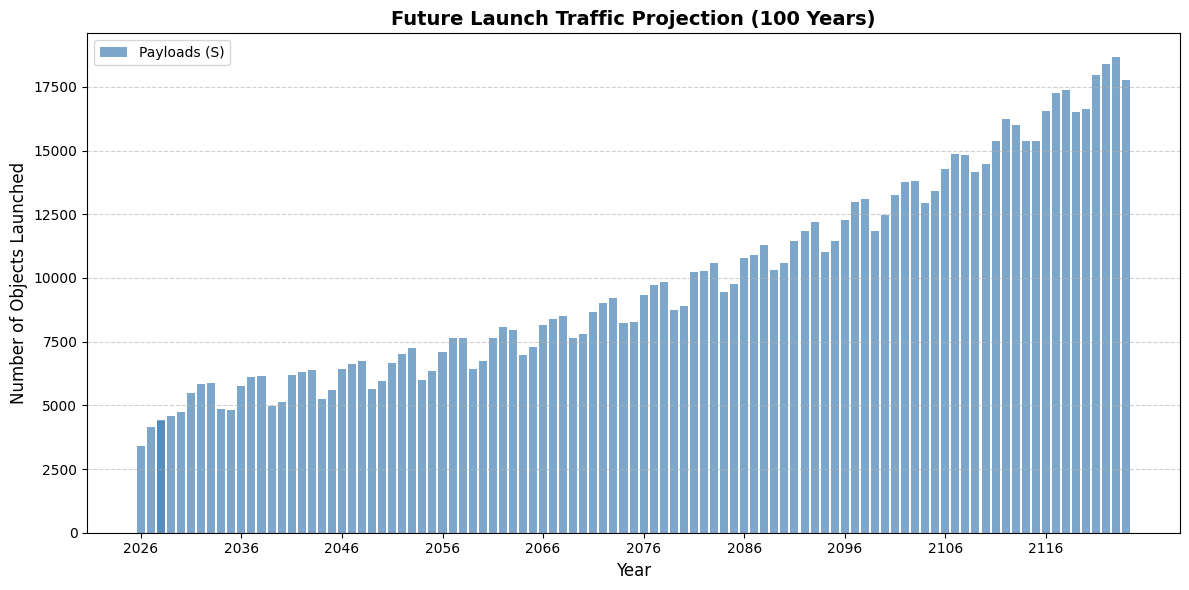

In [7]:
# baseline.FLM_steps
# baseline.FLM_steps['B_5159.74466kg']
# baseline.FLM_steps.loc[:, ~baseline.FLM_steps.columns.str.startswith('B_') & ~baseline.FLM_steps.columns.str.startswith('N_')]

# 1. Prepare the data
df_plot = baseline.FLM_steps.copy()

# Ensure the date column is in datetime format
df_plot['epoch_start_date'] = pd.to_datetime(df_plot['epoch_start_date'])

# 2. Identify species columns (columns that represent object counts)
# We exclude metadata columns
exclude_cols = ['epoch_start_date', 'alt_bin', 'species', 'ecc_bin']
species_cols = [col for col in df_plot.columns if col not in exclude_cols]

# 3. Aggregate: Sum across all altitude bins for each date
# This gives us the total objects per species per year
yearly_traffic = df_plot.groupby('epoch_start_date')[species_cols].sum()

# 4. Calculate categories for a cleaner plot
# Sum columns starting with 'S_' for Payloads
s_cols = [c for c in species_cols if c.startswith('S_')]
yearly_traffic['Total Payloads (S)'] = yearly_traffic[s_cols].sum(axis=1)

# Sum columns starting with 'B_' for Rocket Bodies (if any)
b_cols = [c for c in species_cols if c.startswith('B_')]
if b_cols:
    yearly_traffic['Total Rocket Bodies (B)'] = yearly_traffic[b_cols].sum(axis=1)

# 5. Plotting
plt.figure(figsize=(12, 6))

# Plot the Total Payloads
plt.bar(yearly_traffic.index.year, yearly_traffic['Total Payloads (S)'], 
        alpha=0.7, color='steelblue', label='Payloads (S)')

# Overlay Rocket Bodies if they exist
if b_cols and yearly_traffic['Total Rocket Bodies (B)'].sum() > 0:
    plt.bar(yearly_traffic.index.year, yearly_traffic['Total Rocket Bodies (B)'], 
            bottom=yearly_traffic['Total Payloads (S)'],
            alpha=0.7, color='darkorange', label='Rocket Bodies (B)')

# Formatting
plt.title('Future Launch Traffic Projection (100 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Objects Launched', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

# Set x-ticks to show every 10 years for readability
years = yearly_traffic.index.year
plt.xticks(range(min(years), max(years) + 2, 10))

plt.tight_layout()
plt.show()

In [8]:
# print(baseline.FLM_steps['N_630.64654kg'].sum())
# print(baseline.FLM_steps['N_80.78545kg'].sum())
# print(baseline.FLM_steps['N_18.4772kg'].sum())

# print(baseline.FLM_steps['N_399.7002kg'].sum())
# print(baseline.FLM_steps['N_813.71347kg'].sum())
# print(baseline.FLM_steps['N_2779.91592kg'].sum())

# print(baseline.FLM_steps['S_399.7002kg'].sum())
# print(baseline.FLM_steps['S_813.71347kg'].sum())
# print(baseline.FLM_steps['S_2779.91592kg'].sum())


# 502595 + 298688 + 298688

In [9]:
# print(len(x0_lam))
# print(len(PMD_orig))
# print(len(deltat))
# print(len(x00))
# print(len(var_s))

# 144+72+72+288+288

In [10]:
# # all_input_symbols_for_func = list(var_s) + list(u_var_s) + dist_syms_flat
# print(len(var_s))
# print(len(u_var_s))
# print(len(dist_syms_flat))

# 288*2+216

In [11]:
#==========================================================================
# Launch rate - selection:
# 1. Null 
#       lam_f1(t)
# 2. Time and shell constant based on constant multiplier of the initial population
#       lam_f2(t, const, ref, active_species_indices, N_shell)
# 3. Time and shell varying based on random multiplier of the initial population 
#       lam_f3(t, ref, active_species_per_shells)
# 4. Time and shell varying based on mean and std 
#       lam_f4(t, active_species_per_shells)
# 5. Time and shell based on cosinusoidal function 
#       lam_f5(t, ref, active_species_per_shells)
#==========================================================================

if sel_custom_launches == 1:
    active_species_per_shells = (len(active_indices) + len(rocket_body_indices)) * N_shell
    active_species_indices = active_indices + rocket_body_indices
    # active_species_per_shells = len(active_indices) * N_shell
    # active_species_indices = active_indices

    # Initialize arrays (# species in i-th shells x # time steps)
    x0_lam_no_noise = np.zeros((active_species_per_shells, len(tspan)))
    x0_lam = np.zeros((active_species_per_shells, len(tspan)))

    const = np.concatenate([0.2*np.ones(len(active_indices)), 0*np.ones(len(debris_indices)), 0.1*np.ones(len(rocket_body_indices))])

    # Evaluate lambda functions for each time step
    for i1 in range(len(tspan)):
        x0_lam_no_noise[:, i1] = lam_f1(tspan[i1])
        # x0_lam_no_noise[:, i1] = lam_f2(tspan[i1], const, ref, active_species_indices, N_shell)
        # x0_lam[:, i1] = lam_f1(tspan[i1]) 
    x0_lam = x0_lam_no_noise

# Plot
if sel_launch_rate_plot == 1:
    active_species_indices = active_indices + rocket_body_indices
    launch_rate_plot(baseline, active_species_indices, x0_lam, x0_lam_no_noise, sel_LineWidth, sel_LineWidthAxis, sel_FontSize)

# # Check output
# i1 = 3
# print(x0_lam_no_noise[i1])
# print(sum(x0_lam_no_noise[:,i1]))

#==========================================================================
# PMD - selection:
# 1. Time and shell constant 
#       pmd_f1(t,const, active_species_indices, N_shell)
# 2. Increasing over time, constant for each shell
#       pmd_f2(t,lower_bound,upper_bound, active_species_indices, N_shell, tspan)
# 3. Increasing over time with randomness, constant for each shell
#       pmd_f3(t,lower_bound,upper_bound, active_species_indices, N_shell)
#==========================================================================

# Initialize arrays (# species in i-th shells x # time steps)
active_species_per_shells = len(active_indices) * N_shell
active_species_indices = active_indices
# active_species_per_shells = len(maneuverable_indices) * N_shell
# active_species_indices = maneuverable_indices

PMD_no_noise = np.zeros((active_species_per_shells, len(tspan)))
PMD = np.zeros((active_species_per_shells, len(tspan)))

const = np.concatenate([0.9*np.ones(len(active_indices)), 0*np.ones(len(debris_indices)), 0*np.ones(len(rocket_body_indices))])
# const = np.array([0.9 , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ])
# const = np.array([0.95 , 0.95 , 0.95 , 0.95 , 0. , 0. , 0 , 0 , 0 , 0 , 0])

# Evaluate lambda functions for each time step
for i1 in range(len(tspan)):
    PMD_no_noise[:, i1] = pmd_f1(tspan[i1],const,active_species_indices, N_shell)
    # PMD_no_noise[:, i1] = pmd_f2(tspan[i1],[0.6,0.7,0.8,0.9,0.9,0.9],[0.999,0.999,0.999,0.999,0.999,0.999], active_species_indices, N_shell, tspan)
    # PMD_no_noise[:, i1] = pmd_f3(tspan[i1],[0.6,0.7,0.8,0.9,0.9,0.9],[0.999,0.999,0.999,0.999,0.999,0.999], active_species_indices, N_shell)
    # PMD[:, i1] = pmd_f1(tspan[i1],[0.9,0.9,0.9,0.9,0.8,0.8],active_species_indices, N_shell)
PMD = PMD_no_noise

# Used with sel_pmd_control = 1
PMD_no_noise_orig = copy.deepcopy(PMD_no_noise)
PMD_orig = copy.deepcopy(PMD)

# Plot
if sel_pmd_plot == 1:
    active_species_indices = active_indices
    # active_species_indices = maneuverable_indices
    pmd_plot(baseline, active_species_indices, PMD, PMD_no_noise, sel_LineWidth, sel_LineWidthAxis, sel_FontSize)

#==========================================================================
# Orbital lifetime [years] - selection:
# 1. Time and shell constant 
#      deltat_f1(t,const, active_species_indices, N_shell)  
#==========================================================================

# Initialize arrays (# species in i-th shells x # time steps)
active_species_per_shells = len(active_indices) * N_shell
active_species_indices = active_indices
# active_species_per_shells = len(maneuverable_indices) * N_shell
# active_species_indices = maneuverable_indices

deltat_no_noise = np.zeros((active_species_per_shells, len(tspan)))
deltat = np.zeros((active_species_per_shells, len(tspan)))

# const = np.concatenate([8*np.ones(len(maneuverable_indices)), 3*np.ones(len(list(set(active_indices) - set(maneuverable_indices)))), 0*np.ones(len(debris_indices)), 0*np.ones(len(rocket_body_indices))])
const = np.concatenate([25*np.ones(len(active_indices)), 0*np.ones(len(debris_indices)), 0*np.ones(len(rocket_body_indices))])
# const = np.array([8.0 , 3.0 , 3.0 , 0. , 0. , 0. , 0. , 0. , 0. ])
# const = np.array([6.0 , 6.0 , 6.0 , 15 , 0, 0, 0, 0, 0, 0, 0])

# Evaluate lambda functions for each time step
for i1 in range(len(tspan)):
    deltat_no_noise[:, i1] = deltat_f1(tspan[i1], const, active_species_indices, N_shell)
    # deltat[:, i1] = deltat_f1(tspan[i1],[8,8,8,8,8,8], active_species_indices, N_shell)
deltat = deltat_no_noise

# Plot
if sel_deltat_plot == 1:
    active_species_indices = active_indices
    # active_species_indices = maneuverable_indices
    deltat_plot(baseline, active_species_indices, deltat, deltat_no_noise, sel_LineWidth, sel_LineWidthAxis, sel_FontSize)

#==========================================================================
# Additional parameters selection (TO DO, if needed)
#==========================================================================

# Alpha_no_noise = 0.15 * np.ones_like(tspan) 
# alpha_active_no_noise = 0.015 * np.ones_like(tspan) 
# Delta_no_noise = 5 * np.ones_like(tspan)

# Alpha = Alpha_no_noise + 0 * Alpha_no_noise / 3.5 * np.random.randn(*tspan.shape)
# alpha_active = alpha_active_no_noise + 0 * alpha_active_no_noise / 3.5 * np.random.randn(*tspan.shape)
# Delta = Delta_no_noise + 0 * Delta_no_noise / 3 * np.random.randn(*tspan.shape)

In [12]:
#==========================================================================
# Propagation with control
#==========================================================================

active_species_per_shells = len(active_indices) * N_shell

x00 = x0

if sel_risk_index == 1:
    risk_idx_per_species_per_shell = np.zeros((len(tspan), baseline.species_length*N_shell))
    risk_idx_per_species_per_shell_nc = np.zeros((len(tspan), baseline.species_length*N_shell))
    risk_idx_per_species_per_shell[0] = cum_CSI(x00, baseline)
    risk_idx_per_species_per_shell_nc[0] = cum_CSI(x00, baseline)
elif sel_risk_index == 2:
    risk_idx_per_species_per_shell = np.zeros((len(tspan), baseline.species_length*N_shell))
    risk_idx_per_species_per_shell_nc = np.zeros((len(tspan), baseline.species_length*N_shell))
    risk_idx_per_species_per_shell[0] = cum_umpy(x00, baseline, PMD_no_noise)
    risk_idx_per_species_per_shell_nc[0] = cum_umpy(x00, baseline, PMD_no_noise)
elif sel_risk_index == 3:
    risk_idx_per_species_per_shell_csi = np.zeros((len(tspan), baseline.species_length*N_shell))
    risk_idx_per_species_per_shell_nc_csi = np.zeros((len(tspan), baseline.species_length*N_shell))
    risk_idx_per_species_per_shell_csi[0] = cum_CSI(x00, baseline)
    risk_idx_per_species_per_shell_nc_csi[0] = cum_CSI(x00, baseline)

    risk_idx_per_species_per_shell_umpy = np.zeros((len(tspan), baseline.species_length*N_shell))
    risk_idx_per_species_per_shell_nc_umpy = np.zeros((len(tspan), baseline.species_length*N_shell))
    risk_idx_per_species_per_shell_umpy[0] = cum_umpy(x00, baseline, PMD_no_noise)
    risk_idx_per_species_per_shell_nc_umpy[0] = cum_umpy(x00, baseline, PMD_no_noise)

if sel_controller == 1:
#==========================================================================
# PD
#==========================================================================
    # Initialize arrays
    x_prop_all = np.zeros((len(tspan), baseline.species_length*N_shell))
    u_all = np.zeros((len(tspan), len(u_var_s)))
    x_prop_all[0, :] = x00

    # Start timing
    start_time = time.time()

    for i1 in tqdm( range( len(tspan) - 1 ) ):
        md_no_noise = np.concatenate((x0_lam_no_noise[:, i1], PMD_no_noise[:, i1], deltat_no_noise[:, i1]))
        md = np.concatenate((x0_lam[:, i1], PMD[:, i1], deltat[:, i1]))

        sol = solve_ivp(ode_func, 
                        (tspan[i1], tspan[i1+1]), 
                        x00, 
                        method=baseline.integrator,
                        args=(func,np.zeros(len(u_var_s)),md_no_noise),
                        rtol=rtol, atol=atol)
        x_prop = sol.y[:, -1]
        
        # TO BE USED ONLY WITH x00a below
        # sol_actual = solve_ivp(ode_func, 
        #                 (tspan[i1], tspan[i1+1]), 
        #                 x00, 
        #                 method=baseline.integrator,
        #                 args=(func,np.zeros(len(u_var_s)),md),
        #                 rtol=rtol, atol=atol)
        # x_prop_actual = sol_actual.y[:, -1]

        aaa = list(x_prop) + list(np.zeros(len(u_var_s))) + list(md_no_noise)
        # x_dot_prop = np.array(func(x_prop, np.zeros(len(u_var_s)), md_no_noise)).flatten()
        x_dot_prop = np.array(func(*aaa)).flatten()

        u_list = []
        for i2 in range(baseline.species_length):
            start_idx = i2 * baseline.n_shells
            end_idx = start_idx + baseline.n_shells
            if baseline.species_names[i2].startswith('S'): # Launch rate controllers
                if check_control_launch_sym:
                    u_eval = np.maximum(K_p[i2] * (ref[start_idx:end_idx] - x_prop[start_idx:end_idx]) + K_d[i2] * (ref_dot[start_idx:end_idx] - x_dot_prop[start_idx:end_idx]), 0)
                    u_list = np.concatenate([u_list, u_eval])
                else: 
                    continue
            else: # ADR controllers
                u_eval = np.minimum(K_p[i2] * (ref[start_idx:end_idx] - x_prop[start_idx:end_idx]) + K_d[i2] * (ref_dot[start_idx:end_idx] - x_dot_prop[start_idx:end_idx]), 0)
                if np.sum(u_eval) < satur[i2](tspan[i1+1]):
                    u_eval = u_eval * (satur[i2](tspan[i1+1]) / np.sum(u_eval))
                u_list = np.concatenate([u_list, u_eval])

        # PMD
        if sel_pmd_control == 1:
            PMD_temp = 0
            for i2 in range(baseline.species_length):
                start_idx = i2 * baseline.n_shells
                end_idx = start_idx + baseline.n_shells
                if not baseline.species_names[i2].startswith('S'):
                    #if np.sum(x_prop[start_idx:end_idx]) > np.sum(x_prop_all[i1,start_idx:end_idx]):
                    if np.sum(x_prop[start_idx:end_idx]) > 25000:
                        PMD_temp = PMD_temp + 1
            for i3 in range(active_species_per_shells):
                if PMD_temp > 0:
                    if PMD_no_noise[i3,i1] < 0.95 and PMD[i3,i1] < 0.95:
                        PMD_no_noise[i3,i1+1] = PMD_no_noise[i3,i1] + 0.01
                        PMD[i3,i1+1] = PMD[i3,i1] + 0.01
                    else:
                        PMD_no_noise[i3,i1+1] = 0.95
                        PMD[i3,i1+1] = 0.95
                else:
                    PMD_no_noise[i3,i1+1] = PMD_no_noise[i3,i1]
                    PMD[i3,i1+1] = PMD[i3,i1]

        # x00a = x_prop_actual + u_list
        sol_actual_last = solve_ivp(ode_func, 
                        (tspan[i1], tspan[i1+1]), 
                        x00, 
                        method=baseline.integrator,
                        args=(func, u_list, md),
                        rtol=rtol, atol=atol)
        x_prop_actual_last = sol_actual_last.y[:, -1]
        x00b = x_prop_actual_last # x00b
        # print(np.sum(x00a)-np.sum(x00b))

        x00 = x00b
        x_prop_all[i1+1, :] = x00
        u_all[i1+1, :] = u_list 

        if sel_risk_index == 1:
            risk_idx_per_species_per_shell[i1+1] = cum_CSI(x00, baseline)
        elif sel_risk_index == 2:
            risk_idx_per_species_per_shell[i1+1] = cum_umpy(x00, baseline, PMD_no_noise)
        elif sel_risk_index == 3:
            risk_idx_per_species_per_shell_csi[i1+1] = cum_CSI(x00, baseline)
            risk_idx_per_species_per_shell_umpy[i1+1] = cum_umpy(x00, baseline, PMD_no_noise)
        
    # End timing
    propagation_time = time.time() - start_time 
    mvHistory = u_all.T
    xHistory = x_prop_all.T

elif sel_controller == 2:
#==========================================================================
# NMPC
#==========================================================================

    nx = len(var_s)
    nu = len(u_var_s)
    nd = len(lam_s) + len(Pm_s) + len(deltat_s)

    # Create GEKKO model (similar to nlmpc in MATLAB)


    # Create a stable local directory for GEKKO files
    gekko_dir = "/Users/mayaharris/Documents/GitHub/pyssem/gekko_workspace"
    os.makedirs(gekko_dir, exist_ok=True)

    # Create the model with a fixed workspace
    m = GEKKO(remote=False)
    m.path = gekko_dir

    # Input variables (MVs)
    u = m.Array(m.MV, nu) 
    for i in range(nu):
        u[i].STATUS = 1
        u[i].VALUE = 0

    if check_control_launch_sym:
        for i1 in range(baseline.species_length):
            start_idx = i1 * baseline.n_shells
            end_idx = start_idx + baseline.n_shells
            if baseline.species_names[i1].startswith('S'): 
                for i in range(start_idx,end_idx): 
                    u[i].LOWER = 0 # Launch rate (lambda) minimum 
                    u[i].UPPER = 0 # To use to avoid controller to give positive values to u_l if not used
            else: 
                for i in range(start_idx,end_idx): 
                    u[i].UPPER = 0 # ADR maximum 
    else:
        for i in range(nu): 
            u[i].UPPER = 0 # ADR maximum 

    # State variables (x)
    x = m.Array(m.Var, nx)

    # Measured disturbances (MDs)
    d = m.Array(m.Param, nd) 

    # Set initial conditions for state variables
    for i in range(nx):
        x[i].VALUE = x00[i]
        x[i].LOWER = 0  # Population cannot be negative

    # Define the model equations
    # m.Equations([x[i].dt() == func(x, u, d)[i] for i in range(nx)])
    # gekko_func_input_vars = list(x) + list(u) + list(d)
    # m.Equations([x[i].dt() == func(*gekko_func_input_vars)[i] for i in range(nx)])
    # OR 
    # # --- IMPORTANT: Create the SymPy to Gekko symbol map ---
    # sympy_to_gekko_map = {}
    # # Map state variables (var_s) to Gekko x array
    # for i, sym_var in enumerate(var_s):
    #     sympy_to_gekko_map[sym_var] = x[i]
    # # Map control variables (u_var_s) to Gekko u array
    # for i, sym_u in enumerate(u_var_s):
    #     sympy_to_gekko_map[sym_u] = u[i]
    # # Map disturbance variables (lam_s, Pm_s, deltat_s) to Gekko d array
    # dist_syms = np.concatenate((lam_s, Pm_s, deltat_s)).tolist()
    # for i, sym_d in enumerate(dist_syms):
    #     sympy_to_gekko_map[sym_d] = d[i]
    # # --- Define the model equations using the new helper function ---
    # # Replace the original `func = sp.lambdify(...)` and `m.Equations(...)`
    # intermediate_counter = [0] # Mutable list to hold the counter for unique intermediate names
    # for i in range(nx):
    #     # Convert each SymPy equation to its Gekko equivalent, inserting intermediates
    #     gekko_rhs_expr = _sympy_to_gekko_expr_with_intermediates(
    #         equations_flattened[i], 
    #         sympy_to_gekko_map, 
    #         m, 
    #         complexity_threshold=1000, # Adjust this threshold as needed (e.g., 500, 2000)
    #         counter=intermediate_counter
    #     )
    #     m.Equation(x[i].dt() == gekko_rhs_expr)
    # OR
    # --- IMPORTANT: Create the SymPy to Gekko symbol map ---
    # This map is used by _sympy_to_gekko_expr_with_intermediates
    sympy_to_gekko_map = {}
    for i, sym_var in enumerate(var_s):
        sympy_to_gekko_map[sym_var] = x[i]
    for i, sym_u in enumerate(u_var_s):
        sympy_to_gekko_map[sym_u] = u[i]
    dist_syms_flat_gekko = list(d) # This matches your `d` Gekko array
    for i, sym_d in enumerate(dist_syms_flat): # Iterate over original SymPy dist names
        sympy_to_gekko_map[sym_d] = d[i] # Map SymPy disturbance symbols to Gekko 'd' array elements
    
    # --------------------------------------------------------------------------
    # NEW: Define the model equations piece by piece for ALL equations
    # --------------------------------------------------------------------------
    intermediate_counter = [0] # Mutable list for unique intermediate names

    print(f"Defining {nx} differential equations piece by piece (Gekko expressions) for ALL equations.")
    print("-" * 50) # Separator for clarity

    for i in range(nx): # nx is total number of equations (e.g., 15*3 = 45)
        current_eq_sympy = equations_flattened[i] # The full SymPy expression for this equation
        
        # --- DIAGNOSTIC PRINT ---
        # Print the length of the full SymPy expression for all equations.
        print(f"Eq {i}: Full SymPy expression length: {len(str(current_eq_sympy))}")
        # --------------------------

        gekko_rhs_expr = _sympy_to_gekko_expr_with_intermediates(
            current_eq_sympy,       # This list now contains rounded SymPy expressions
            sympy_to_gekko_map,     # Map SymPy symbols to Gekko variables
            m, 
            apply_intermediates = True, # <--- ALWAYS TRUE, applying to all equations
            complexity_threshold=5, # <--- **CRITICAL TUNING**: Start here. Try 200, 50, 20.
            counter=intermediate_counter
        )
        m.Equation(x[i].dt() == gekko_rhs_expr)

    print("-" * 50)
    print(f"Defined {nx} differential equations for Gekko. Total intermediates created: {intermediate_counter[0]}.")
    # --------------------------------------------------------------------------

    # Set objective function:
    if sel_nmpc_cost_function == 0:
        # Quadratic cost function: state-reference tracking
        # m.Obj(myCostFunction(x, u, ref))
        # OR
        x_cost = m.Intermediate( m.sum( ( x - ref )**2 ) )
        m.Minimize(x_cost)
    elif sel_nmpc_cost_function == 1:
        # CSI-based risk index cost function
        risk_idx_vars = myCostFunction_CSI(m, x, baseline)
        objective_terms = [ risk_idx_vars[i] for i in range(len(u)) ]
        m.Minimize( m.sum(objective_terms) )
    elif sel_nmpc_cost_function == 2:
        # UMPY-based risk index cost function
        risk_idx_vars = myCostFunction_UMPY(m, x, baseline)
        objective_terms = [ risk_idx_vars[i] for i in range(len(u)) ]
        m.Minimize( m.sum(objective_terms) )
        # # OR
        # risk_idx_vars = myCostFunction_UMPY(m, x, baseline)
        # w_risk = m.Param(value=100.0) # High value means we really want to reduce risk
        # w_control = m.Param(value=1.0)  # Penalizes using too much control
        # state_cost = w_risk * m.sum(risk_idx_vars)
        # control_cost = w_control * m.sum([u_i**2 for u_i in u])
        # m.Minimize(state_cost + control_cost)
    
    # Set inequality constraints
    satur_eval_list = []
    for i1 in range(baseline.species_length):
        start_idx = i1 * baseline.n_shells
        end_idx = start_idx + baseline.n_shells
        if not baseline.species_names[i1].startswith('S'):
            satur_eval = m.Param(value=satur[i1](tspan[0]))  
            satur_eval_list.append(satur_eval)
            # m.Equations([-np.sum(u[start_idx:end_idx]) + satur_eval <= 0])
            m.Equations([-m.sum(u[start_idx:end_idx]) + satur_eval <= 0]) # GEKKO max legnth issue
        else:
            satur_eval_list.append(0)
    
    # Solver options
    m.options.IMODE = 6  # MPC mode
    m.options.CV_TYPE = 2 # squared error
    m.options.NODES = 2  # Collocation points (WARNING: 3 was not working)
    m.options.SOLVER = 1  # 1: APOPT, 2: BPOPT, 3: IPOPT.
    # IPOPT is generally the best for problems with large numbers of 
    # degrees of freedom or when starting without a good initial guess. 
    # BPOPT has been found to be the best for systems biology applications. 
    # APOPT is generally the best when warm-starting from a prior solution 
    # or when the number of degrees of freedom (Number of Variables - Number
    # of Equations) is less than 2000. APOPT is also the only solver that 
    # handles Mixed Integer problems. Use option 0 to compare all available solvers.
    
    # Set sampling time, prediction horizon, and control horizon
    m.options.TIME_SHIFT = 1
    # m.options.OTOL = 1e-2
    # m.options.RTOL = 1e-2
    
    print(f"\nSampling Time: {m.options.TIME_SHIFT*Ts:.2f} y")
    print(f"\nPrediction Horizon steps: {Tp}")
    # print(f"\nControl Horizon steps: {Tc}")
    print(f"\nPrediction time: {Ts*Tp:.2f} y")
    print(f"\nSimulation time: {dur:.2f} y\n\n")
        
    # Simulation loop
    xHistory = x00
    xeval = x00
    mvHistory = np.zeros(nu)
    start_time = time.time()
    for ct in tqdm( range( len(tspan) - 1 ) ):
        m.time = np.linspace(tspan[ct], tspan[ct+1], 2)
        # m.time = np.linspace(ct, (Tp*Ts) + ct, Tp+1)

        for i1 in range(baseline.species_length):
            if not baseline.species_names[i1].startswith('S'): 
                satur_eval_list[i1].value = satur[i1](m.time)

        md_no_noise = np.concatenate((x0_lam_no_noise[:, ct], PMD_no_noise[:, ct], deltat_no_noise[:, ct]))
        md = np.concatenate((x0_lam[:,ct], PMD[:, ct], deltat[:, ct]))

        # Update measured disturbances         
        for i in range(nd):
            d[i].VALUE = md_no_noise[i]

        # Solve the optimization problem
        # m.solve(disp=False)

        os.chdir(gekko_dir)
        step_dir = os.path.join(gekko_dir, f"step_{ct}")
        os.makedirs(step_dir, exist_ok=True)
        m.path = step_dir
        # print("Working directory exists:", os.path.isdir(m.path))

        try:
            m.solve(disp=False)
        except Exception as e:
            # print(f"\n--- Solver failed at step {tspan[ct]}. Rerunning with display enabled. ---")
            # m.solve(disp=True)
            m.solve(disp=False)

        # Get optimal control moves
        ueval = []
        for i in range(nu):
            u[i].VALUE = u[i][1]
            ueval = np.append(ueval, u[i].VALUE)

        # Update initial conditions for next time step
        sol = solve_ivp(ode_func, 
                        (tspan[ct], tspan[ct+1]), 
                        xeval, 
                        method=baseline.integrator,
                        args=(func,ueval,md),
                        rtol=rtol, atol=atol)
        xeval = sol.y[:, -1]
        
        for i in range(nx):
            x[i].VALUE = xeval[i]

        if sel_pmd_control == 1:
            PMD_temp = 0
            debris_pop_temp = 0
            active_pop_temp = 0
            for i2 in range(baseline.species_length):
                start_idx = i2 * baseline.n_shells
                end_idx = start_idx + baseline.n_shells
                if not baseline.species_names[i2].startswith('S'):
                    debris_pop_temp += np.sum(xeval[start_idx:end_idx])
                else:
                    active_pop_temp += np.sum(xeval[start_idx:end_idx])
                    #if np.sum(xeval[start_idx:end_idx]) > 25000:
                    #    PMD_temp = PMD_temp + 1
            if (3 * active_pop_temp) < debris_pop_temp:
                print("PMD controller check:")
                print(active_pop_temp, debris_pop_temp)
                PMD_temp = PMD_temp + 1
            for i3 in range(active_species_per_shells):
                if PMD_temp > 0:
                    if PMD_no_noise[i3,ct] < 1.0 and PMD[i3,ct] < 1.0:
                        PMD_no_noise[i3,ct+1] = PMD_no_noise[i3,ct] + 0.01
                        PMD[i3,ct+1] = PMD[i3,ct] + 0.01
                    else:
                        PMD_no_noise[i3,ct+1] = 1.0
                        PMD[i3,ct+1] = 1.0
                else:
                    PMD_no_noise[i3,ct+1] = PMD_no_noise[i3,ct]
                    PMD[i3,ct+1] = PMD[i3,ct]

        # Store history
        xHistory = np.column_stack([xHistory,xeval])
        mvHistory = np.column_stack([mvHistory,ueval])

        if sel_risk_index == 1:
            risk_idx_per_species_per_shell[ct+1] = cum_CSI(xeval, baseline)
        elif sel_risk_index == 2:
            risk_idx_per_species_per_shell[ct+1] = cum_umpy(xeval, baseline, PMD_no_noise)
        elif sel_risk_index == 3:
            risk_idx_per_species_per_shell_csi[ct+1] = cum_CSI(xeval, baseline)
            risk_idx_per_species_per_shell_umpy[ct+1] = cum_umpy(xeval, baseline, PMD_no_noise)

    propagation_time = time.time() - start_time

# print(f"Propagation time: {propagation_time:.4f} seconds")
t_prop = tspan

# TO DO
# x_dot_prop = np.array(func(x_prop.T, np.zeros(len(u_var_s)), md)).flatten()
# x_dot_prop = x_dot_prop.reshape((len(tspan), len(var_s)))

#==========================================================================
# Propagation without control
#==========================================================================

x00 = x0
x_prop_nc = np.zeros((len(tspan), baseline.species_length*N_shell))
x_prop_nc[0, :] = x00

# if np.sum(x0_lam) == 0: # Use the lambda values from the control solution
# x0_lam2 = mvHistory[:active_species_per_shells,:]     

start_time = time.time()
for i1 in tqdm( range( len(tspan) - 1 ) ):
    # if np.sum(x0_lam2) != 0:
        # md = np.concatenate((x0_lam2[:, i1+1], PMD_orig[:, i1], deltat[:, i1])) 
    # else:
    md = np.concatenate((x0_lam[:, i1], PMD_orig[:, i1], deltat[:, i1])) 
    sol = solve_ivp(ode_func, 
                    (tspan[i1], tspan[i1+1]), 
                    x00, 
                    method=baseline.integrator,
                    args=(func,np.zeros(len(u_var_s)),md),
                    # args=(func, np.concatenate([lam_prop[i1+1]*1, adr_n_prop[i1]*0, adr_d_prop[i1]*0], axis=0), md),
                    rtol=rtol, atol=atol)
    x_prop_nc[i1+1, :] = sol.y[:, -1]
    x00 = sol.y[:, -1]

    if sel_risk_index == 1:
        risk_idx_per_species_per_shell_nc[i1+1] = cum_CSI(x00, baseline)
    elif sel_risk_index == 2:
        risk_idx_per_species_per_shell_nc[i1+1] = cum_umpy(x00, baseline, PMD_no_noise)
    elif sel_risk_index == 3:
        risk_idx_per_species_per_shell_nc_csi[i1+1] = cum_CSI(x00, baseline)
        risk_idx_per_species_per_shell_nc_umpy[i1+1] = cum_umpy(x00, baseline, PMD_no_noise)

propagation_time = time.time() - start_time
print(f"Propagation time (no control): {propagation_time:.4f} seconds")    
t_prop_nc = tspan

if sel_controller == 0:
    x_prop_all = x_prop_nc
    u_all = np.zeros((len(tspan), len(u_var_s)))
    mvHistory = u_all.T
    xHistory = x_prop_all.T
    t_prop = t_prop_nc



100%|██████████| 100/100 [01:30<00:00,  1.11it/s]

Propagation time (no control): 90.2424 seconds


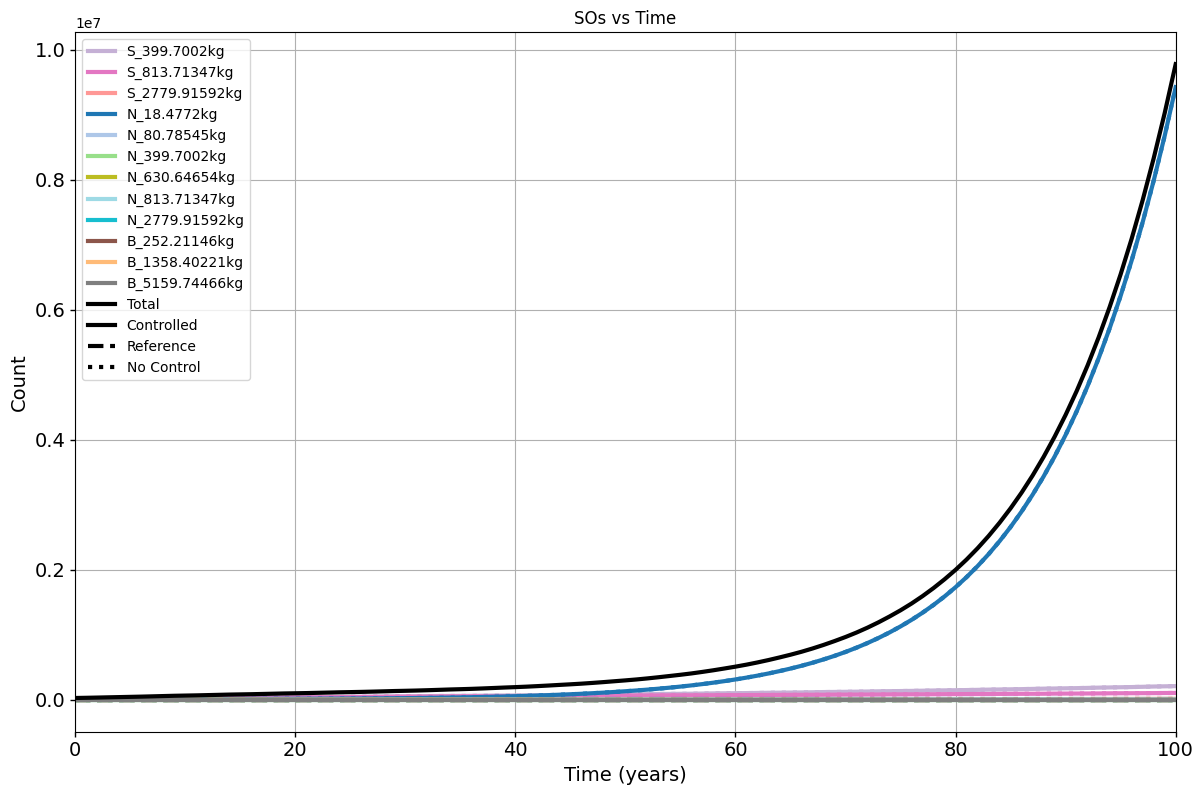

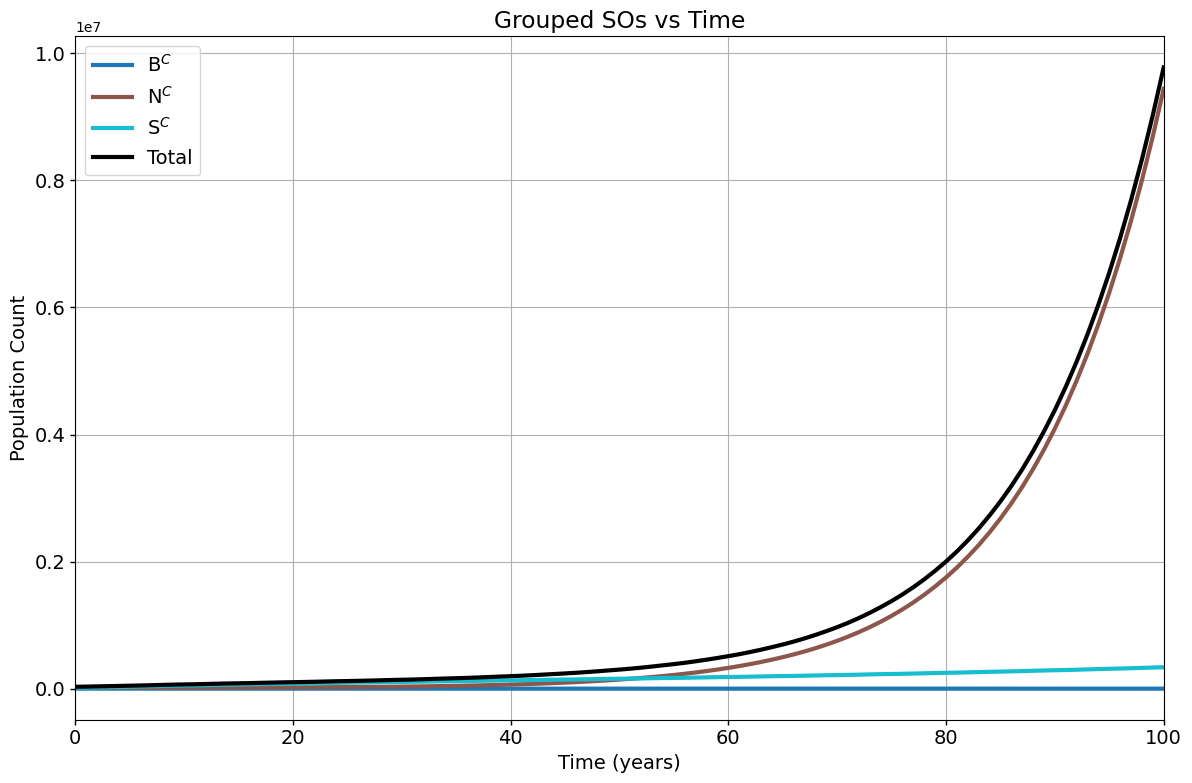

In [13]:
#==========================================================================
# Variable definition for plots
#==========================================================================
# size = (42,101)
baseline.output = {}
baseline.output['t'] = t_prop
baseline.output['y'] = xHistory
baseline.output['y_nc'] = x_prop_nc.T
baseline.output['y_u'] = mvHistory
# if sel_ic == 3:
baseline.output['y_ref'] = np.tile(ref, (len(t_prop), 1)).T
baseline.output['ydot_ref'] = np.tile(ref_dot, (len(t_prop), 1)).T
# else:
#     baseline.output['y_ref'] = np.concatenate([np.tile(ref_S, (len(t_prop), 1)), np.tile(ref_N, (len(t_prop), 1)), np.tile(ref_D, (len(t_prop), 1))], axis=1).T
#     baseline.output['ydot_ref'] = np.concatenate([np.tile(ref_S_dot, (len(t_prop), 1)), np.tile(ref_N_dot, (len(t_prop), 1)), np.tile(ref_D_dot, (len(t_prop), 1))], axis=1).T
# size = (101,)
baseline.output['satur'] = satur
baseline.output['PMD'] = PMD
baseline.output['PMD_no_noise'] = PMD_no_noise
baseline.output['PMD_orig'] = PMD_orig
baseline.output['PMD_no_noise_orig'] = PMD_no_noise_orig
if sel_risk_index == 3:
    baseline.output['risk_idx_per_species_per_shell_csi'] = risk_idx_per_species_per_shell_csi.T
    baseline.output['risk_idx_per_species_per_shell_nc_csi'] = risk_idx_per_species_per_shell_nc_csi.T
    baseline.output['risk_idx_per_species_per_shell_umpy'] = risk_idx_per_species_per_shell_umpy.T
    baseline.output['risk_idx_per_species_per_shell_nc_umpy'] = risk_idx_per_species_per_shell_nc_umpy.T
elif sel_risk_index:
    baseline.output['risk_idx_per_species_per_shell'] = risk_idx_per_species_per_shell.T
    baseline.output['risk_idx_per_species_per_shell_nc'] = risk_idx_per_species_per_shell_nc.T

output = CreateOutput(baseline.output)
n_species = baseline.species_length
num_shells = baseline.n_shells
species_names = baseline.species_names
orbital_shell_labels = baseline.R0_km[:num_shells]
markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', '*', 'h']

base_species_names = baseline.species_names
unique_base_species = list(set(base_species_names))
color_map = plt.get_cmap('tab20', len(unique_base_species))

#==========================================================================
# Plots
#==========================================================================
if sel_cumulative_plot == 1:
    cumulative_plot(baseline, output, active_species_indices, sel_pmd_control, sel_risk_index, sel_LineWidth, sel_LineWidthAxis, sel_FontSize)


In [14]:
# Save spreadsheet

print(base_species_names)

# 1. Access the raw data
# Shape is (288, 101) -> 12 species * 24 shells = 288 rows
y_nc = baseline.output['y_nc'] 

# 2. Reshape to separate species and shells
# New shape: (12 species, 24 shells, 101 years)
reshaped_data = y_nc.reshape(n_species, num_shells, len(baseline.output['t']))

# 3. Sum across altitude shells (axis 1) 
# Result shape: (12 species, 101 years)
species_sum = reshaped_data.sum(axis=1)

# 4. Define Index Mapping (based on the order provided)
# Index: 0:S_399, 1:S_813, 2:S_2779, 3:N_18, 4:N_80, 5:N_399(D), 
#        6:N_630, 7:N_813(D), 8:N_2779(D), 9:B_252, 10:B_1358, 11:B_5159
payload_indices = [0, 1, 2, 5, 7, 8]  # All S + N-Derelicts (same mass as S)
debris_indices  = [3, 4, 6]           # Remaining N (Fragments)
rb_indices      = [9, 10, 11]         # All B

# 5. Aggregate into Excel Columns
years = np.arange(2026, 2026 + len(baseline.output['t']))

# Sum the specific rows for each category
payloads_col = species_sum[payload_indices, :].sum(axis=0)
old_debris_col = species_sum[debris_indices, :].sum(axis=0)
rocket_bodies_col = species_sum[rb_indices, :].sum(axis=0)

# Calculate "New Debris generated" (Annual delta of fragments)
# We assume the first year (2026) has 0 "newly generated" debris
new_debris_gen = np.diff(old_debris_col, prepend=old_debris_col[0])
new_debris_gen[new_debris_gen < 0] = 0 # Ignore decreases due to atmospheric decay

# 6. Construct the DataFrame
df_export = pd.DataFrame({
    'Year': years,
    'Old Debris': old_debris_col,
    'New Debris generated': new_debris_gen,
    'Payloads': payloads_col,
    'Rocket Bodies': rocket_bodies_col,
    'MRO': 0,             # Placeholder as requested
    'Constellations': 0,  # Placeholder as requested
})

# Calculate Total
df_export['Total'] = df_export[['Old Debris', 'New Debris generated', 'Payloads', 'Rocket Bodies']].sum(axis=1)

# 7. Save to Excel
output_file = "output_N_objs_baseline_ssem.xlsx"
df_export.to_excel(output_file, index=False, sheet_name='Mean')

print(f"File saved successfully: {output_file}")

['S_399.7002kg', 'S_813.71347kg', 'S_2779.91592kg', 'N_18.4772kg', 'N_80.78545kg', 'N_399.7002kg', 'N_630.64654kg', 'N_813.71347kg', 'N_2779.91592kg', 'B_252.21146kg', 'B_1358.40221kg', 'B_5159.74466kg']
File saved successfully: output_N_objs_baseline_ssem.xlsx


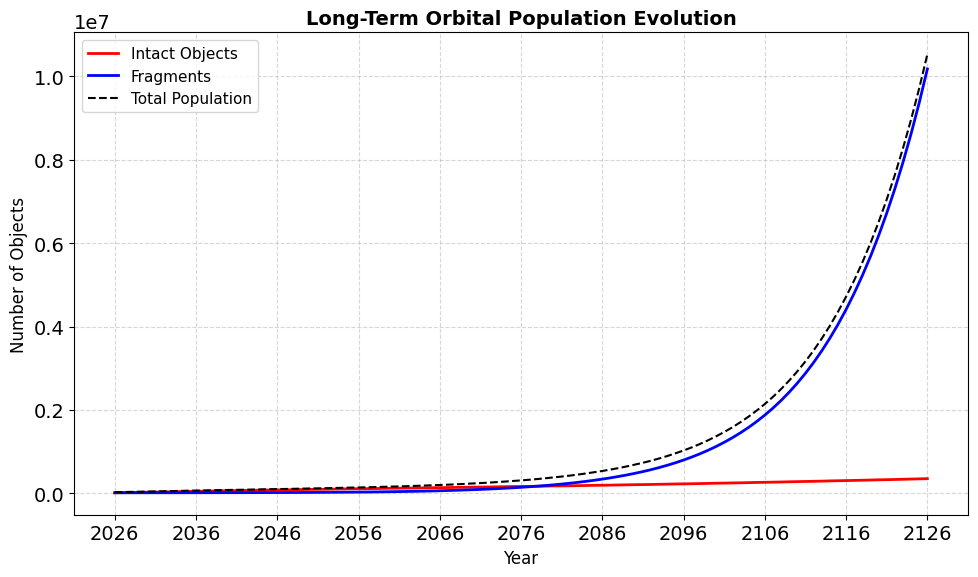

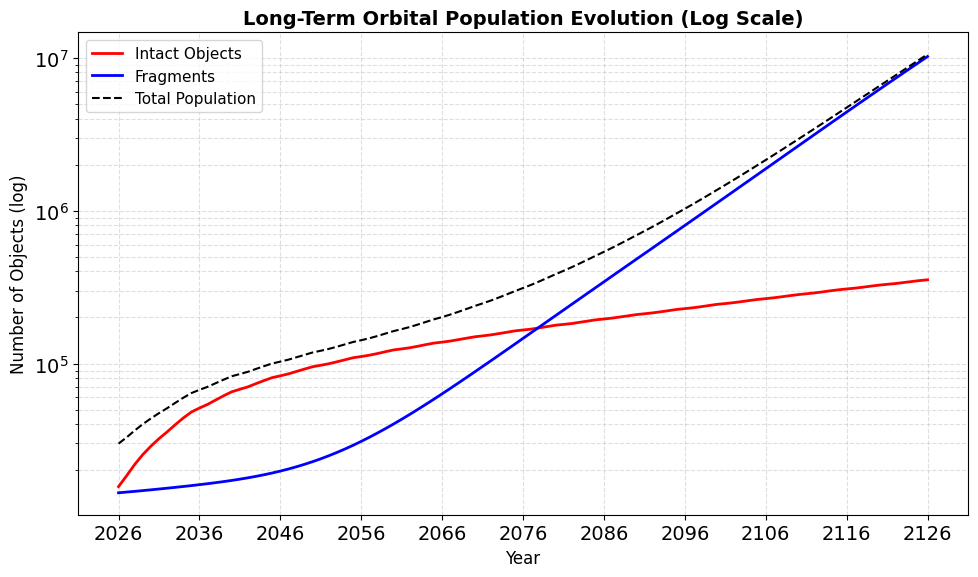

In [15]:
# 1. Load the data from the spreadsheet created in the previous step
file_path = "output_N_objs_baseline_ssem.xlsx"
df = pd.read_excel(file_path, sheet_name='Mean')

# 2. Define the categories for plotting
# Intact = Payloads + Rocket Bodies + MRO + Constellations
df['Intact_Total'] = df['Payloads'] + df['Rocket Bodies'] + df['MRO'] + df['Constellations']

# Fragments = Old Debris + New Debris generated
df['Fragments_Total'] = df['Old Debris'] + df['New Debris generated']

# 3. Create the plot
plt.figure(figsize=(10, 6), dpi=100)

# Plotting the three lines
plt.plot(df['Year'], df['Intact_Total'], label='Intact Objects', color='red', linewidth=2)
plt.plot(df['Year'], df['Fragments_Total'], label='Fragments', color='blue', linewidth=2)
plt.plot(df['Year'], df['Total'], label='Total Population', color='black', linestyle='--', linewidth=1.5)

# 4. Styling the plot
plt.title('Long-Term Orbital Population Evolution', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Objects', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Ensure X-axis shows relevant years clearly
plt.xticks(range(int(df['Year'].min()), int(df['Year'].max()) + 5, 10))

# Display the plot
plt.tight_layout()
plt.show()

# 3. Create the Logarithmic Plot
plt.figure(figsize=(10, 6), dpi=100)

# Use semilogy for a log scale on the Y axis
plt.semilogy(df['Year'], df['Intact_Total'], label='Intact Objects', color='red', linewidth=2)
plt.semilogy(df['Year'], df['Fragments_Total'], label='Fragments', color='blue', linewidth=2)
plt.semilogy(df['Year'], df['Total'], label='Total Population', color='black', linestyle='--', linewidth=1.5)

# 4. Styling the plot
plt.title('Long-Term Orbital Population Evolution (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Objects (log)', fontsize=12)

# For log plots, 'both' grid lines (major and minor) are very helpful
plt.grid(True, which='both', linestyle='--', alpha=0.4)

# Set lower limit to 1 (or higher) because log(0) is undefined
# plt.ylim(bottom=1) 

plt.legend(fontsize=11, loc='upper left')

# Ensure X-axis shows relevant years clearly
plt.xticks(range(int(df['Year'].min()), int(df['Year'].max()) + 5, 10))

# Display the plot
plt.tight_layout()
plt.show()

In [16]:
#==========================================================================
# Collision rate
#==========================================================================
# The description of make_active_loss_per_shell says: 
# "Calculates the indicator variable for number of active spacecraft lost in each orbit shell to collision events in a given year. "
# In a 3 species case, I would have those: col_rate_SS, col_rate_SD, col_rate_SN, col_rate_DD, col_rate_DN, col_rate_NN. 
# Each indicator represents the collision rate of a species versus all the other ones:
# - S_aggregate_collisions = col_rate_SS + col_rate_SD + col_rate_SN
# - N_aggregate_collisions = col_rate_SN + col_rate_DN + col_rate_NN
# - N_200kg_aggregate_collisions = col_rate_SD + col_rate_DD + col_rate_DN

from utils.indicators.indicators import make_active_loss_per_shell

baseline.indicator_variables_list = []
percentage = False  # False uses absolute number, true gives the percentage
per_species = True # True returns values for each species as independent, false sums by shell
per_pair = False
baseline.indicator_variables_list.append(make_active_loss_per_shell(baseline, percentage, per_species, per_pair))

baseline.indicator_results['indicators'] = {}
for i in baseline.indicator_variables_list:
    for indicator_var in i:
        simplified_eqs = sp.simplify(indicator_var.eqs)
        indicator_fun = sp.lambdify(baseline.all_symbolic_vars, simplified_eqs, 'numpy')
        evaluated_indicator_dict = {}
        # Iterate over states (rows in y) and corresponding time steps (t)
        for state, t in zip(output.y.T, output.t):
            evaluated_value = indicator_fun(*state)
            evaluated_indicator_dict[t] = evaluated_value
        # Store the results for this indicator in the results dictionary
        baseline.indicator_results['indicators'][indicator_var.name] = evaluated_indicator_dict

collision_rate = {}
for indicator_name, time_values in baseline.indicator_results['indicators'].items():
    print(f"Indicator: {indicator_name}")
    times = np.array(list(time_values.keys()))  # Time array
    indicator_matrix = np.array([np.squeeze(values) for values in time_values.values()])  # Shape: [num_times, num_shells]
    collision_rate_per_year = np.sum(indicator_matrix, axis=1)
    collision_rate[indicator_name[:-21]] = {
        'times': times,
        'indicator_matrix': indicator_matrix, # The full (times x shells) matrix
        'rate_per_year': collision_rate_per_year # The summed (times,) vector
    }

# # Example: How to access and use the results
# print("\n--- Final Processed Collision Rate Results ---")
# for species_name, results_dict in collision_rate.items():
#     print(f"Results for: {species_name}")
#     print(f"  - Shape of matrix (times x shells): {results_dict['indicator_matrix'].shape}")
#     print(f"  - Total collision rate in the first year: {results_dict['rate_per_year'][0]:.2f}")


#==========================================================================
# Conjunction rate | Collision Avoidance (CA) Counter
#==========================================================================
# from utils.indicators.indicators import make_ca_counter
# # make_ca_counter(scen_properties, primary_species_list, secondary_species_list, per_species=False, ind_name="", per_spacecraft=False)

# # 1. Create a lookup dictionary for fast access to species properties by name.
# # This is much more efficient than searching in a loop.
# species_props_map = {
#     prop.sym_name: prop 
#     for species_list in baseline.species_cells.values() 
#     for prop in species_list
# }

# # This dictionary will store the final, processed results.
# ca_counter_results = {}

# print("\n--- Generating and Evaluating CA Counter Indicators ---")

# # 2. Outer loop: Iterate through each species using your robust method.
# for species_class, species_list_in_class in baseline.species_cells.items():
#     for primary_species_properties in species_list_in_class:
        
#         # Filter for active primary species
#         if not primary_species_properties.sym_name.startswith('S'):
#             continue

#         primary_species_name = primary_species_properties.sym_name
#         #print(f"Processing CAMs for primary species: {primary_species_name}...")
        
#         # Initialize a symbolic expression to accumulate the total CAs
#         total_ca_eqs_for_primary = sp.zeros(baseline.n_shells, 1)

#         # 3. Inner loop: Sum the interactions with all other species
#         for secondary_species_name in baseline.species_names:
        
#             # Retrieve the full properties object for the secondary species using our map.
#             secondary_species_properties = species_props_map[secondary_species_name]
            
#             # Now pass the full objects to the function.
#             indicator_var_list = make_ca_counter(
#                 baseline,
#                 primary_species_list=[primary_species_properties],
#                 secondary_species_list=[secondary_species_properties]
#             )

#             # Check if the returned list is not empty before trying to access its elements.
#             # Then, access the first element [0] to get the actual indicator object.
#             if indicator_var_list and indicator_var_list[0].eqs is not None:
#                 total_ca_eqs_for_primary += indicator_var_list[0].eqs

#         # 4. Lambdify, evaluate, and store the results (this part remains the same)
#         simplified_eqs = sp.simplify(total_ca_eqs_for_primary)
#         indicator_fun = sp.lambdify(baseline.all_symbolic_vars, simplified_eqs, 'numpy')

#         evaluated_indicator_dict = {}
#         for state, t in zip(output.y.T, output.t):
#             evaluated_value = indicator_fun(*state)
#             evaluated_indicator_dict[t] = evaluated_value

#         times = np.array(list(evaluated_indicator_dict.keys()))
#         indicator_matrix = np.array([np.squeeze(values) for values in evaluated_indicator_dict.values()])
#         ca_maneuvers_per_year = np.sum(indicator_matrix, axis=1)

#         ca_counter_results[primary_species_name] = {
#             'times': times,
#             'indicator_matrix': indicator_matrix,
#             'maneuvers_per_year': ca_maneuvers_per_year
#         }

# # Example: How to access and use the results
# print("\n--- Final Processed CA Counter Results ---")
# for species_name, results_dict in ca_counter_results.items():
#     print(f"Results for: {species_name}")
#     print(f"  - Shape of matrix (times x shells): {results_dict['indicator_matrix'].shape}")
#     print(f"  - Total maneuvers in the first year: {results_dict['maneuvers_per_year'][0]:.2f}")


Indicator: S_399.7002kg_aggregate_collisions
Indicator: S_813.71347kg_aggregate_collisions
Indicator: S_2779.91592kg_aggregate_collisions
Indicator: N_18.4772kg_aggregate_collisions
Indicator: N_80.78545kg_aggregate_collisions
Indicator: N_399.7002kg_aggregate_collisions
Indicator: N_630.64654kg_aggregate_collisions
Indicator: N_813.71347kg_aggregate_collisions
Indicator: N_2779.91592kg_aggregate_collisions
Indicator: B_252.21146kg_aggregate_collisions
Indicator: B_1358.40221kg_aggregate_collisions
Indicator: B_5159.74466kg_aggregate_collisions


In [17]:
# --- 1. Data Preparation ---
y_nc = baseline.output['y_nc']  # Shape (288, 101)
# Reshape to (12 species, 24 shells, 101 years)
pop_data = y_nc.reshape(12, 24, 101)

# Indices based on your specific species order:
# Intact: S (0,1,2), N-Derelicts (5,7,8), B (9,10,11)
# Fragments: N-Frags (3,4,6)
intact_idx = [0, 1, 2, 5, 7, 8, 9, 10, 11]
frag_idx   = [3, 4, 6]

# --- 2. Calculate Cumulative Lambda (Events) ---
total_losses = np.zeros((101, 24)) 
for results_dict in collision_rate.values():
    total_losses += results_dict['indicator_matrix']

# Divide by 2 (2 objects lost per 1 event) and integrate over time
total_events_rate = total_losses / 2
cum_lambda = np.cumsum(total_events_rate, axis=0) 

# --- 3. Define Altitude Range Mapping ---
# Simulation covers 200 to 2000 km with 24 shells
shell_edges = np.linspace(200, 2000, 25)
shell_centers = (shell_edges[:-1] + shell_edges[1:]) / 2

# Define the target Excel ranges
bin_edges = np.arange(200, 2200, 200) # [200, 400, ..., 2000]
bin_labels = [f"{bin_edges[i]}-{bin_edges[i+1]} km" for i in range(len(bin_edges)-1)]

# Map each of the 24 shells to one of the 9 Excel bins
# np.digitize returns 1 for 200-400, 2 for 400-600, etc.
shell_to_bin = np.digitize(shell_centers, bin_edges)

# --- 4. Extract Data for Target Years ---
target_years = [2026, 2051, 2076, 2101, 2126]
time_indices = [0, 25, 50, 75, 100]

data_rows = []
for b_idx in range(1, len(bin_edges)):
    label = bin_labels[b_idx-1]
    row = {'Altitude_Range': label}
    
    # Indices of the SSEM shells that fall within this specific range
    shells_in_range = np.where(shell_to_bin == b_idx)[0]
    
    for y_val, t_idx in zip(target_years, time_indices):
        if len(shells_in_range) > 0:
            # Sum population
            intact = pop_data[intact_idx, :, t_idx][:, shells_in_range].sum()
            frags  = pop_data[frag_idx, :, t_idx][:, shells_in_range].sum()
            
            # Cumulative Pc = 1 - exp(-Expected Events in this range)
            l_sum = cum_lambda[t_idx, shells_in_range].sum()
            pc = 1 - np.exp(-l_sum)
        else:
            intact, frags, pc = 0, 0, 0
            
        row[f'Intact_{y_val}'] = intact
        row[f'Fragments_{y_val}'] = frags
        row[f'Cumulative_Pc_{y_val}'] = pc
        
    data_rows.append(row)

# --- 5. Export to Excel ---
df_final = pd.DataFrame(data_rows)
output_filename = f"output_pc_bins_baseline_ssem.xlsx"
df_final.to_excel(output_filename, index=False)

print(f"Spreadsheet generated successfully: {output_filename}")

Spreadsheet generated successfully: output_pc_bins_baseline_ssem.xlsx


In [18]:
# 1. Setup Time and categories
years = np.arange(2026, 2026 + 101)
payload_annual = np.zeros(101)
debris_annual = np.zeros(101)
rb_annual = np.zeros(101)

# List of masses that identify a Derelict (even if they start with 'N_')
derelict_masses = ['399.7002', '813.71347', '2779.91592']

for name, data in collision_rate.items():
    annual_rate = data['rate_per_year'] / 2 
    
    # 1. Check if it's an Active Satellite (S_) or a Derelict (N_ with specific mass)
    is_payload = 'S_' in name or any(m in name for m in derelict_masses)
    
    # 2. Check if it's a Rocket Body
    is_rb = 'B_' in name
    
    if is_payload:
        payload_annual += annual_rate
    elif is_rb:
        rb_annual += annual_rate
    else:
        # If it's not S, not a Derelict mass, and not B, it's pure Debris
        debris_annual += annual_rate

# 3. Create the DataFrame
df_colls = pd.DataFrame({
    'Year': years,
    'Expected_Payload_Collisions': payload_annual,
    'Expected_Debris_Collisions': debris_annual,
    'Expected_RB_Collisions': rb_annual,
    'Total_Annual_Expected_Collisions': payload_annual + debris_annual + rb_annual
})

# 4. Calculate Cumulative Collisions (useful for verification)
df_colls['Cumulative_Expected_Collisions'] = df_colls['Total_Annual_Expected_Collisions'].cumsum()

# 5. Save to Excel
output_path = "output_collision_rates_baseline_ssem.xlsx"
df_colls.to_excel(output_path, index=False, sheet_name='Annual_Data')

print(f"Collision rates saved to: {output_path}")

# Display the first few rows to verify
print(df_colls.head())

Collision rates saved to: output_collision_rates_baseline_ssem.xlsx
   Year  Expected_Payload_Collisions  Expected_Debris_Collisions  \
0  2026                     0.008278                    0.077835   
1  2027                     0.011248                    0.080187   
2  2028                     0.013775                    0.082326   
3  2029                     0.016156                    0.084423   
4  2030                     0.018438                    0.086484   

   Expected_RB_Collisions  Total_Annual_Expected_Collisions  \
0                0.053403                          0.139516   
1                0.053131                          0.144567   
2                0.052912                          0.149013   
3                0.052785                          0.153364   
4                0.052718                          0.157640   

   Cumulative_Expected_Collisions  
0                        0.139516  
1                        0.284082  
2                        0.433096  


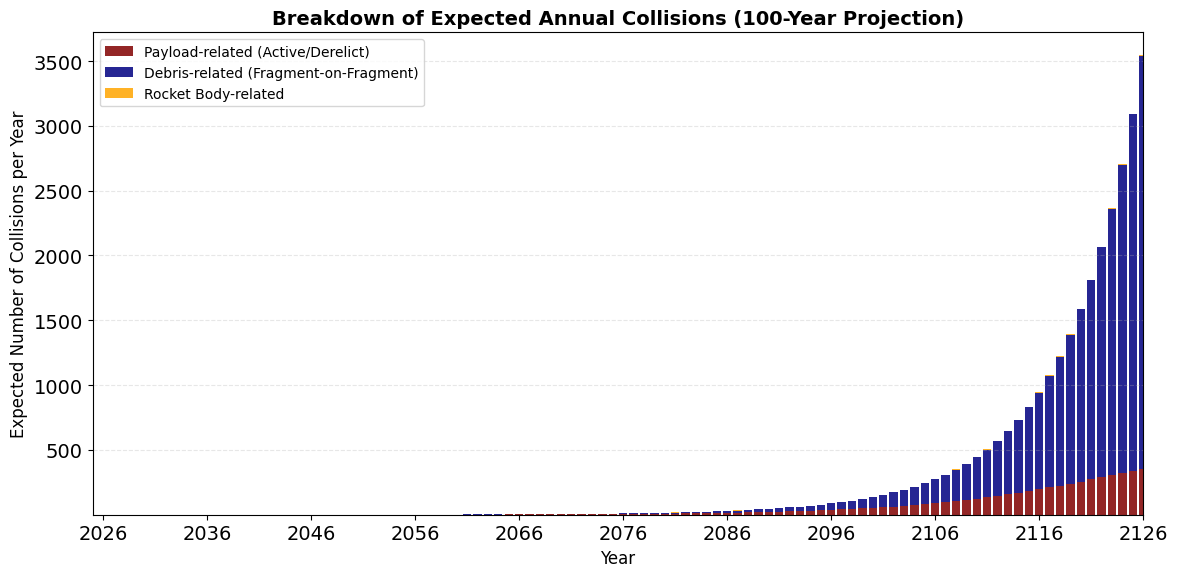

In [19]:
# Load the fixed data
df_colls = pd.read_excel("output_collision_rates_baseline_ssem.xlsx")

plt.figure(figsize=(12, 6), dpi=100)

# Create the stacked bar chart
plt.bar(df_colls['Year'], df_colls['Expected_Payload_Collisions'], 
        label='Payload-related (Active/Derelict)', color='maroon', alpha=0.85)

plt.bar(df_colls['Year'], df_colls['Expected_Debris_Collisions'], 
        bottom=df_colls['Expected_Payload_Collisions'],
        label='Debris-related (Fragment-on-Fragment)', color='navy', alpha=0.85)

plt.bar(df_colls['Year'], df_colls['Expected_RB_Collisions'], 
        bottom=df_colls['Expected_Payload_Collisions'] + df_colls['Expected_Debris_Collisions'],
        label='Rocket Body-related', color='orange', alpha=0.85)

# Formatting
plt.title('Breakdown of Expected Annual Collisions (100-Year Projection)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Expected Number of Collisions per Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=10)

# Set X-axis to show every 10 years
plt.xticks(range(2026, 2127, 10))
plt.xlim(2025, 2126)

plt.tight_layout()
plt.show()

In [20]:
# --- Sanity Check Script ---
print(f"{'Species Name':<25} | {'Year 1 Rate':<10}")
print("-" * 40)
total_check = 0
for name, data in collision_rate.items():
    val = data['rate_per_year'][0]
    total_check += val
    print(f"{name:<25} | {val:.6f}")

print("-" * 40)
print(f"{'SUM OF ALL INDICATORS':<25} | {total_check:.6f}")
print(f"{'ACTUAL COLLISION EVENTS':<25} | {total_check/2:.6f}")

Species Name              | Year 1 Rate
----------------------------------------
S_399.7002kg              | 0.000000
S_813.71347kg             | 0.000000
S_2779.91592kg            | 0.000000
N_18.4772kg               | 0.106805
N_80.78545kg              | 0.048309
N_399.7002kg              | 0.013366
N_630.64654kg             | 0.000555
N_813.71347kg             | 0.003068
N_2779.91592kg            | 0.000122
B_252.21146kg             | 0.004766
B_1358.40221kg            | 0.068625
B_5159.74466kg            | 0.033415
----------------------------------------
SUM OF ALL INDICATORS     | 0.279032
ACTUAL COLLISION EVENTS   | 0.139516


In [21]:
# #==========================================================================
# # Collision rate
# #==========================================================================
# # The description of make_active_loss_per_shell says: 
# # "Calculates the indicator variable for number of active spacecraft lost in each orbit shell to collision events in a given year. "
# # In a 3 species case, I would have those: col_rate_SS, col_rate_SD, col_rate_SN, col_rate_DD, col_rate_DN, col_rate_NN. 
# # Each indicator represents the collision rate of a species versus all the other ones:
# # - S_aggregate_collisions = col_rate_SS + col_rate_SD + col_rate_SN
# # - N_aggregate_collisions = col_rate_SN + col_rate_DN + col_rate_NN
# # - N_200kg_aggregate_collisions = col_rate_SD + col_rate_DD + col_rate_DN

# from utils.indicators.indicators import make_active_loss_per_shell

# baseline.indicator_variables_list = []
# percentage = False  # False uses absolute number, true gives the percentage
# per_species = True # True returns values for each species as independent, false sums by shell
# baseline.indicator_variables_list.append(make_active_loss_per_shell(baseline, percentage, per_species))

# baseline.indicator_results['indicators'] = {}
# for i in baseline.indicator_variables_list:
#     for indicator_var in i:
#         simplified_eqs = sp.simplify(indicator_var.eqs)
#         indicator_fun = sp.lambdify(baseline.all_symbolic_vars, simplified_eqs, 'numpy')
#         evaluated_indicator_dict = {}
#         # Iterate over states (rows in y) and corresponding time steps (t)
#         for state, t in zip(output.y.T, output.t):
#             evaluated_value = indicator_fun(*state)
#             evaluated_indicator_dict[t] = evaluated_value
#         # Store the results for this indicator in the results dictionary
#         baseline.indicator_results['indicators'][indicator_var.name] = evaluated_indicator_dict

# collision_rate = {}
# for indicator_name, time_values in baseline.indicator_results['indicators'].items():
#     # print(f"Indicator: {indicator_name}")
#     times = np.array(list(time_values.keys()))  # Time array
#     indicator_matrix = np.array([np.squeeze(values) for values in time_values.values()])  # Shape: [num_times, num_shells]
#     collision_rate_per_year = np.sum(indicator_matrix, axis=1)
#     collision_rate[indicator_name[:-21]] = {
#         'times': times,
#         'indicator_matrix': indicator_matrix, # The full (times x shells) matrix
#         'rate_per_year': collision_rate_per_year # The summed (times,) vector
#     }

# # Example: How to access and use the results
# print("\n--- Final Processed Collision Rate Results ---")
# for species_name, results_dict in collision_rate.items():
#     print(f"Results for: {species_name}")
#     print(f"  - Shape of matrix (times x shells): {results_dict['indicator_matrix'].shape}")
#     print(f"  - Total collision rate in the first year: {results_dict['rate_per_year'][0]:.2f}")


# #==========================================================================
# # Conjunction rate | Collision Avoidance (CA) Counter
# #==========================================================================
# from utils.indicators.indicators import make_ca_counter
# # make_ca_counter(scen_properties, primary_species_list, secondary_species_list, per_species=False, ind_name="", per_spacecraft=False)

# # 1. Create a lookup dictionary for fast access to species properties by name.
# # This is much more efficient than searching in a loop.
# species_props_map = {
#     prop.sym_name: prop 
#     for species_list in baseline.species_cells.values() 
#     for prop in species_list
# }

# # This dictionary will store the final, processed results.
# ca_counter_results = {}

# print("\n--- Generating and Evaluating CA Counter Indicators ---")

# # 2. Outer loop: Iterate through each species using your robust method.
# for species_class, species_list_in_class in baseline.species_cells.items():
#     for primary_species_properties in species_list_in_class:
        
#         # Filter for active primary species
#         if not primary_species_properties.sym_name.startswith('S'):
#             continue

#         primary_species_name = primary_species_properties.sym_name
#         print(f"Processing CAMs for primary species: {primary_species_name}...")
        
#         # Initialize a symbolic expression to accumulate the total CAs
#         total_ca_eqs_for_primary = sp.zeros(baseline.n_shells, 1)

#         # 3. Inner loop: Sum the interactions with all other species
#         for secondary_species_name in baseline.species_names:
        
#             # Retrieve the full properties object for the secondary species using our map.
#             secondary_species_properties = species_props_map[secondary_species_name]
            
#             # Now pass the full objects to the function.
#             indicator_var_list = make_ca_counter(
#                 baseline,
#                 primary_species_list=[primary_species_properties],
#                 secondary_species_list=[secondary_species_properties]
#             )

#             # Check if the returned list is not empty before trying to access its elements.
#             # Then, access the first element [0] to get the actual indicator object.
#             if indicator_var_list and indicator_var_list[0].eqs is not None:
#                 total_ca_eqs_for_primary += indicator_var_list[0].eqs

#         # 4. Lambdify, evaluate, and store the results (this part remains the same)
#         simplified_eqs = sp.simplify(total_ca_eqs_for_primary)
#         indicator_fun = sp.lambdify(baseline.all_symbolic_vars, simplified_eqs, 'numpy')

#         evaluated_indicator_dict = {}
#         for state, t in zip(output.y.T, output.t):
#             evaluated_value = indicator_fun(*state)
#             evaluated_indicator_dict[t] = evaluated_value

#         times = np.array(list(evaluated_indicator_dict.keys()))
#         indicator_matrix = np.array([np.squeeze(values) for values in evaluated_indicator_dict.values()])
#         ca_maneuvers_per_year = np.sum(indicator_matrix, axis=1)

#         ca_counter_results[primary_species_name] = {
#             'times': times,
#             'indicator_matrix': indicator_matrix,
#             'maneuvers_per_year': ca_maneuvers_per_year
#         }

# # Example: How to access and use the results
# print("\n--- Final Processed CA Counter Results ---")
# for species_name, results_dict in ca_counter_results.items():
#     print(f"Results for: {species_name}")
#     print(f"  - Shape of matrix (times x shells): {results_dict['indicator_matrix'].shape}")
#     print(f"  - Total maneuvers in the first year: {results_dict['maneuvers_per_year'][0]:.2f}")


# #==========================================================================
# # To save/load output and plot results in the future
# #==========================================================================
# data_to_save = (baseline, output, active_species_indices, 
#                 sel_pmd_control, sel_risk_index, sel_LineWidth, sel_LineWidthAxis, sel_FontSize,
#                 adr_initial, time_increment_in_years, adr_increment_per_species, adr_species)
# with open('result_nmpc_adr_umpy.dill', 'wb') as f:  
#     dill.dump(data_to_save, f)

# with open('result_nmpc_adr_umpy.dill', 'rb') as f:  
#     loaded_data = dill.load(f)
# baseline, output, active_species_indices, sel_pmd_control, sel_risk_index, sel_LineWidth, sel_LineWidthAxis, sel_FontSize, adr_initial, time_increment_in_years, adr_increment_per_species, adr_species = loaded_data

# n_species = baseline.species_length
# num_shells = baseline.n_shells
# species_names = baseline.species_names
# orbital_shell_labels = baseline.R0_km[:num_shells]
# markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', '*', 'h']

# base_species_names = baseline.species_names
# unique_base_species = list(set(base_species_names))
# color_map = plt.get_cmap('tab20', len(unique_base_species))

# cumulative_plot(baseline, output, active_species_indices, sel_pmd_control, sel_risk_index, sel_LineWidth, sel_LineWidthAxis, sel_FontSize)
